# **Problem Statement - Part A**

## Context

In the realm of modern finance, businesses encounter the perpetual challenge of managing debt obligations effectively to maintain a favorable credit standing and foster sustainable growth. Investors keenly scrutinize companies capable of navigating financial complexities while ensuring stability and profitability. A pivotal instrument in this evaluation process is the balance sheet, which provides a comprehensive overview of a company's assets, liabilities, and shareholder equity, offering insights into its financial health and operational efficiency. In this context, leveraging available financial data, particularly from preceding fiscal periods, becomes imperative for informed decision-making and strategic planning.

## Objective

A group of venture capitalists want to develop a Financial Health Assessment Tool. With the help of the tool, it endeavors to empower businesses and investors with a robust mechanism for evaluating the financial well-being and creditworthiness of companies. By harnessing machine learning techniques, they aim to analyze historical financial statements and extract pertinent insights to facilitate informed decision-making via the tool. Specifically, they foresee facilitating the following with the help of the tool:

1. Debt Management Analysis: Identify patterns and trends in debt management practices to assess the ability of businesses to fulfill financial obligations promptly and efficiently, and identify potential cases of default.
2. Credit Risk Evaluation: Evaluate credit risk exposure by analyzing liquidity ratios, debt-to-equity ratios, and other key financial indicators to ascertain the likelihood of default and inform investment decisions.

They have hired you as a data scientist and provided you with the financial metrics of different companies. The task is to analyze the data provided and develop a predictive model leveraging machine learning techniques to identify whether a given company will be tagged as a defaulter in terms of net worth next year. The predictive model will help the organization anticipate potential challenges with the financial performance of the companies and enable proactive risk mitigation strategies.

## Data Dictionary

The data consists of financial metrics from the balance sheets of different companies. The detailed data dictionary is given below.

* Networth Next Year: Net worth of the customer in the next year
* Total assets: Total assets of customer
* Net worth: Net worth of the customer of the present year
* Total income: Total income of the customer
* Change in stock: Difference between the current value of the stock and the value of stock in the last trading day
* Total expenses: Total expenses done by the customer
* Profit after tax: Profit after tax deduction
* PBDITA: Profit before depreciation, income tax, and amortization
* PBT: Profit before tax deduction
* Cash profit: Total Cash profit
* PBDITA as % of total income: PBDITA / Total income
* PBT as % of total income: PBT / Total income
* PAT as % of total income: PAT / Total income
* Cash profit as % of total income: Cash Profit / Total income
* PAT as % of net worth: PAT / Net worth
* Sales: Sales done by the customer
* Income from financial services: Income from financial services
* Other income: Income from other sources
* Total capital: Total capital of the customer
* Reserves and funds: Total reserves and funds of the customer
* Borrowings: Total amount borrowed by the customer
* Current liabilities & provisions: current liabilities of the customer
* Deferred tax liability: Future income tax customer will pay because of the current transaction
* Shareholders funds: Amount of equity in a company which belongs to shareholders
* Cumulative retained profits: Total cumulative profit retained by customer
* Capital employed: Current asset minus current liabilities
* TOL/TNW: Total liabilities of the customer divided by Total net worth
* Total term liabilities / tangible net worth: Short + long term liabilities divided by tangible net worth
* Contingent liabilities / Net worth (%): Contingent liabilities / Net worth
* Contingent liabilities: Liabilities because of uncertain events
* Net fixed assets: The purchase price of all fixed assets
* Investments: Total invested amount
* Current assets: Assets that are expected to be converted to cash within a year
* Net working capital: Difference between the current liabilities and current assets
* Quick ratio (times): Total cash divided by current liabilities
* Current ratio (times): Current assets divided by current liabilities
* Debt to equity ratio (times): Total liabilities divided by its shareholder equity
* Cash to current liabilities (times): Total liquid cash divided by current liabilities
* Cash to average cost of sales per day: Total cash divided by the average cost of the sales
* Creditors turnover: Net credit purchase divided by average trade creditors
* Debtors turnover: Net credit sales divided by average accounts receivable
* Finished goods turnover: Annual sales divided by average inventory
* WIP turnover: The cost of goods sold for a period divided by the average inventory for that period
* Raw material turnover: Cost of goods sold is divided by the average inventory for the same period
* Shares outstanding: Number of issued shares minus the number of shares held in the company
* Equity face value: cost of the equity at the time of issuing
* EPS: Net income divided by the total number of outstanding share
* Adjusted EPS: Adjusted net earnings divided by the weighted average number of common shares outstanding on a diluted basis during the plan year
* Total liabilities: Sum of all types of liabilities
* PE on BSE: Company's current stock price divided by its earnings per share



**Note:** A company will not be tagged as a defaulter if its net worth next year is positive, or else, it'll be tagged as a defaulter.

# Importing necessary libraries

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, GridSearchCV    # Train test Split and Grid Search
from sklearn.ensemble import RandomForestClassifier

import statsmodels.api as SM
from sklearn import metrics

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

from IPython.core.display import display, HTML
display(HTML('<style>.container { width:90% !important; }<\style>'))

# Loading the Data

In [ ]:
# loading the data from drive
from google.colab import drive
drive.mount('/content/drive/')
df = pd.read_csv('/content/drive/My Drive/Comp_Fin_Data.csv')
df.head()

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


,Num,Networth Next Year,Total assets,Net worth,Total income,Change in stock,Total expenses,Profit after tax,PBDITA,PBT,...,Debtors turnover,Finished goods turnover,WIP turnover,Raw material turnover,Shares outstanding,Equity face value,EPS,Adjusted EPS,Total liabilities,PE on BSE
0,1,395.3,827.6,336.5,534.1,13.5,508.7,38.9,124.4,64.6,...,5.65,3.99,3.37,14.87,8760056.0,10.0,4.44,4.44,827.6,NaN
1,2,36.2,67.7,24.3,137.9,-3.7,131.0,3.2,5.5,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,67.7,NaN
2,3,84.0,238.4,78.9,331.2,-18.1,309.2,3.9,25.8,10.5,...,2.51,17.67,8.76,8.35,NaN,NaN,0.00,0.00,238.4,NaN
3,4,2041.4,6883.5,1443.3,8448.5,212.2,8482.4,178.3,418.4,185.1,...,1.91,18.14,18.62,11.11,10000000.0,10.0,17.60,17.60,6883.5,NaN
4,5,41.8,90.9,47.0,388.6,3.4,392.7,-0.7,7.2,-0.6,...,68.00,45.87,28.67,19.93,107315.0,100.0,-6.52,-6.52,90.9,NaN


Fixing messy column names (containing spaces) for ease of use

In [ ]:
df.columns = df.columns.str.replace(' ', '_').str.replace('(', '').str.replace(')', '').str.replace('%', 'perc').str.replace('/', '_to_')

# Data Overview

In [ ]:
# viewing the first 5 rows of the data
df.head()

,Num,Networth_Next_Year,Total_assets,Net_worth,Total_income,Change_in_stock,Total_expenses,Profit_after_tax,PBDITA,PBT,...,Debtors_turnover,Finished_goods_turnover,WIP_turnover,Raw_material_turnover,Shares_outstanding,Equity_face_value,EPS,Adjusted_EPS,Total_liabilities,PE_on_BSE
0,1,395.3,827.6,336.5,534.1,13.5,508.7,38.9,124.4,64.6,...,5.65,3.99,3.37,14.87,8760056.0,10.0,4.44,4.44,827.6,NaN
1,2,36.2,67.7,24.3,137.9,-3.7,131.0,3.2,5.5,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,67.7,NaN
2,3,84.0,238.4,78.9,331.2,-18.1,309.2,3.9,25.8,10.5,...,2.51,17.67,8.76,8.35,NaN,NaN,0.00,0.00,238.4,NaN
3,4,2041.4,6883.5,1443.3,8448.5,212.2,8482.4,178.3,418.4,185.1,...,1.91,18.14,18.62,11.11,10000000.0,10.0,17.60,17.60,6883.5,NaN
4,5,41.8,90.9,47.0,388.6,3.4,392.7,-0.7,7.2,-0.6,...,68.00,45.87,28.67,19.93,107315.0,100.0,-6.52,-6.52,90.9,NaN


In [ ]:
# viewing the last 5 rows of the data
df.tail()

,Num,Networth_Next_Year,Total_assets,Net_worth,Total_income,Change_in_stock,Total_expenses,Profit_after_tax,PBDITA,PBT,...,Debtors_turnover,Finished_goods_turnover,WIP_turnover,Raw_material_turnover,Shares_outstanding,Equity_face_value,EPS,Adjusted_EPS,Total_liabilities,PE_on_BSE
4251,4252,0.2,0.4,0.2,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,NaN,NaN,0.00,NaN,NaN,0.00,0.00,0.4,NaN
4252,4253,93.3,159.6,86.7,172.9,0.1,169.7,3.3,18.4,3.7,...,1.80,11.00,8.28,9.88,8162700.0,10.0,0.42,0.42,159.6,16.81
4253,4254,932.2,833.8,664.6,2314.7,32.1,2151.6,195.2,348.4,303.0,...,6.08,59.28,31.14,9.87,7479762.0,10.0,26.58,26.58,833.8,5.69
4254,4255,64.6,95.0,48.5,110.5,4.6,113.5,1.6,9.7,2.6,...,3.71,78.99,11.51,14.95,NaN,NaN,0.00,0.00,95.0,NaN
4255,4256,0.0,384.6,111.3,345.8,11.3,341.7,15.4,57.6,20.7,...,4.71,53.37,8.33,3.74,960000.0,10.0,15.63,15.63,384.6,NaN


In [ ]:
# Checking the shape of the dataset
print('The number of rows (observations) is',df.shape[0],'\n''The number of columns (variables) is',df.shape[1])

The number of rows (observations) is 4256 
The number of columns (variables) is 51


In [ ]:
# checking the column names and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4256 entries, 0 to 4255
Data columns (total 51 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Num                                             4256 non-null   int64  
 1   Networth_Next_Year                              4256 non-null   float64
 2   Total_assets                                    4256 non-null   float64
 3   Net_worth                                       4256 non-null   float64
 4   Total_income                                    4025 non-null   float64
 5   Change_in_stock                                 3706 non-null   float64
 6   Total_expenses                                  4091 non-null   float64
 7   Profit_after_tax                                4102 non-null   float64
 8   PBDITA                                          4102 non-null   float64
 9   PBT                                      

In [ ]:
# checking for no. of unique values
df.nunique()

,0
Num,4256
Networth_Next_Year,2574
Total_assets,2961
Net_worth,2376
Total_income,2870
Change_in_stock,1164
Total_expenses,2898
Profit_after_tax,1467
PBDITA,1826
PBT,1568


Statistical Summary of the given Datasets

In [ ]:
# Numerical Data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Num,4256.0,2.128500e+03,1.228746e+03,1.000000e+00,1064.750,2128.500,3.192250e+03,4.256000e+03
Networth_Next_Year,4256.0,1.344741e+03,1.593674e+04,-7.426560e+04,3.975,72.100,3.308250e+02,8.057734e+05
Total_assets,4256.0,3.573617e+03,3.007444e+04,1.000000e-01,91.300,315.500,1.120800e+03,1.176509e+06
Net_worth,4256.0,1.351950e+03,1.296131e+04,0.000000e+00,31.475,104.800,3.898500e+02,6.131516e+05
Total_income,4025.0,4.688190e+03,5.391895e+04,0.000000e+00,107.100,455.100,1.485000e+03,2.442828e+06
Change_in_stock,3706.0,4.370248e+01,4.369150e+02,-3.029400e+03,-1.800,1.600,1.840000e+01,1.418550e+04
Total_expenses,4091.0,4.356301e+03,5.139809e+04,-1.000000e-01,96.800,426.800,1.395700e+03,2.366035e+06
Profit_after_tax,4102.0,2.950506e+02,3.079902e+03,-3.908300e+03,0.500,9.000,5.330000e+01,1.194391e+05
PBDITA,4102.0,6.059406e+02,5.646231e+03,-4.407000e+02,6.925,36.900,1.587000e+02,2.085765e+05
PBT,4102.0,4.102590e+02,4.217415e+03,-3.894800e+03,0.800,12.600,7.417500e+01,1.452926e+05


In [ ]:
pd.options.display.float_format = '{:.2f}'.format

df.describe()

,Num,Networth_Next_Year,Total_assets,Net_worth,Total_income,Change_in_stock,Total_expenses,Profit_after_tax,PBDITA,PBT,...,Debtors_turnover,Finished_goods_turnover,WIP_turnover,Raw_material_turnover,Shares_outstanding,Equity_face_value,EPS,Adjusted_EPS,Total_liabilities,PE_on_BSE
count,4256.00,4256.00,4256.00,4256.00,4025.00,3706.00,4091.00,4102.00,4102.00,4102.00,...,3871.00,3382.00,3492.00,3828.00,3446.00,3446.00,4256.00,4256.00,4256.00,1629.00
mean,2128.50,1344.74,3573.62,1351.95,4688.19,43.70,4356.30,295.05,605.94,410.26,...,17.93,84.37,28.68,17.73,23764909.56,-1094.83,-196.22,-197.53,3573.62,55.46
std,1228.75,15936.74,30074.44,12961.31,53918.95,436.92,51398.09,3079.90,5646.23,4217.42,...,90.16,562.64,169.65,343.13,170979041.33,34101.36,13061.95,13061.93,30074.44,1304.45
min,1.00,-74265.60,0.10,0.00,0.00,-3029.40,-0.10,-3908.30,-440.70,-3894.80,...,0.00,-0.09,-0.18,-2.00,-2147483647.00,-999998.90,-843181.82,-843181.82,0.10,-1116.64
25%,1064.75,3.98,91.30,31.48,107.10,-1.80,96.80,0.50,6.93,0.80,...,3.81,8.19,5.10,3.02,1308382.50,10.00,0.00,0.00,91.30,2.97
50%,2128.50,72.10,315.50,104.80,455.10,1.60,426.80,9.00,36.90,12.60,...,6.47,17.32,9.86,6.41,4750000.00,10.00,1.49,1.24,315.50,8.69
75%,3192.25,330.82,1120.80,389.85,1485.00,18.40,1395.70,53.30,158.70,74.17,...,11.85,40.01,20.24,11.82,10906020.00,10.00,10.00,7.62,1120.80,17.00
max,4256.00,805773.40,1176509.20,613151.60,2442828.20,14185.50,2366035.30,119439.10,208576.50,145292.60,...,3135.20,17947.60,5651.40,21092.00,4130400545.00,100000.00,34522.53,34522.53,1176509.20,51002.74


Creating a binary target variable using 'Networth_Next_Year'

In [ ]:
df['default'] = np.where((df['Networth_Next_Year'] > 0), 0, 1)

In [ ]:
# Checking top 10 rows
df[['default','Networth_Next_Year']].head(10)

,default,Networth_Next_Year
0,0,395.30
1,0,36.20
2,0,84.00
3,0,2041.40
4,0,41.80
5,0,291.50
6,0,93.30
7,0,985.10
8,0,188.60
9,0,229.60


In [ ]:
# Checking the count of the default
df['default'].value_counts()

,count
default,
0,3352
1,904


In [ ]:
# Checking the proportion of the default
df['default'].value_counts(normalize = True)

,proportion
default,
0,0.79
1,0.21


In [ ]:
# checking for duplicate values
df.duplicated().sum()

0

In [ ]:
# checking for missing values in the data
df.isnull().sum()

,0
Num,0
Networth_Next_Year,0
Total_assets,0
Net_worth,0
Total_income,231
Change_in_stock,550
Total_expenses,165
Profit_after_tax,154
PBDITA,154
PBT,154


In [ ]:
df.size

221312

In [ ]:
df.isnull().sum().sum()

17778

There are missing Values in the dataset

#Exploratory Data Analysis

## Univariate Analysis

In [ ]:
df.head()

,Num,Networth_Next_Year,Total_assets,Net_worth,Total_income,Change_in_stock,Total_expenses,Profit_after_tax,PBDITA,PBT,...,Finished_goods_turnover,WIP_turnover,Raw_material_turnover,Shares_outstanding,Equity_face_value,EPS,Adjusted_EPS,Total_liabilities,PE_on_BSE,default
0,1,395.30,827.60,336.50,534.10,13.50,508.70,38.90,124.40,64.60,...,3.99,3.37,14.87,8760056.00,10.00,4.44,4.44,827.60,NaN,0
1,2,36.20,67.70,24.30,137.90,-3.70,131.00,3.20,5.50,1.00,...,NaN,NaN,NaN,NaN,NaN,0.00,0.00,67.70,NaN,0
2,3,84.00,238.40,78.90,331.20,-18.10,309.20,3.90,25.80,10.50,...,17.67,8.76,8.35,NaN,NaN,0.00,0.00,238.40,NaN,0
3,4,2041.40,6883.50,1443.30,8448.50,212.20,8482.40,178.30,418.40,185.10,...,18.14,18.62,11.11,10000000.00,10.00,17.60,17.60,6883.50,NaN,0
4,5,41.80,90.90,47.00,388.60,3.40,392.70,-0.70,7.20,-0.60,...,45.87,28.67,19.93,107315.00,100.00,-6.52,-6.52,90.90,NaN,0


In [ ]:
df.shape

(4256, 52)

In [ ]:
  ## Checking unique values in the mentioned column
  df["default"].unique()

array([0, 1])

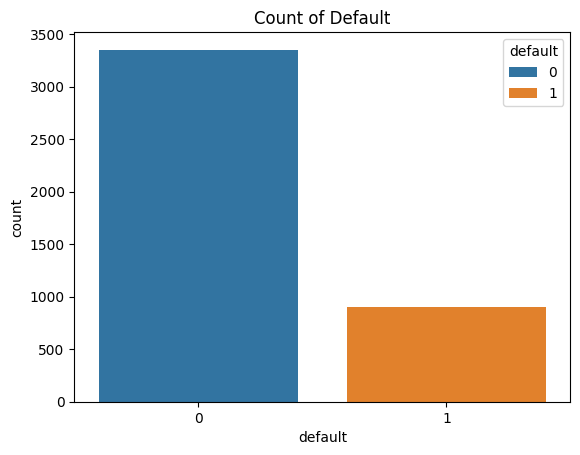

In [ ]:
#Plotting a countplot for the target variable
sns.countplot(x = "default", data = df, hue = 'default')   ## Complete the code to get a countplot of the mentionedd column.
plt.title('Count of Default')
plt.show()

In [ ]:
#Percentage of defaulters
(df.default.sum()/len(df)) * 100

21.2406015037594

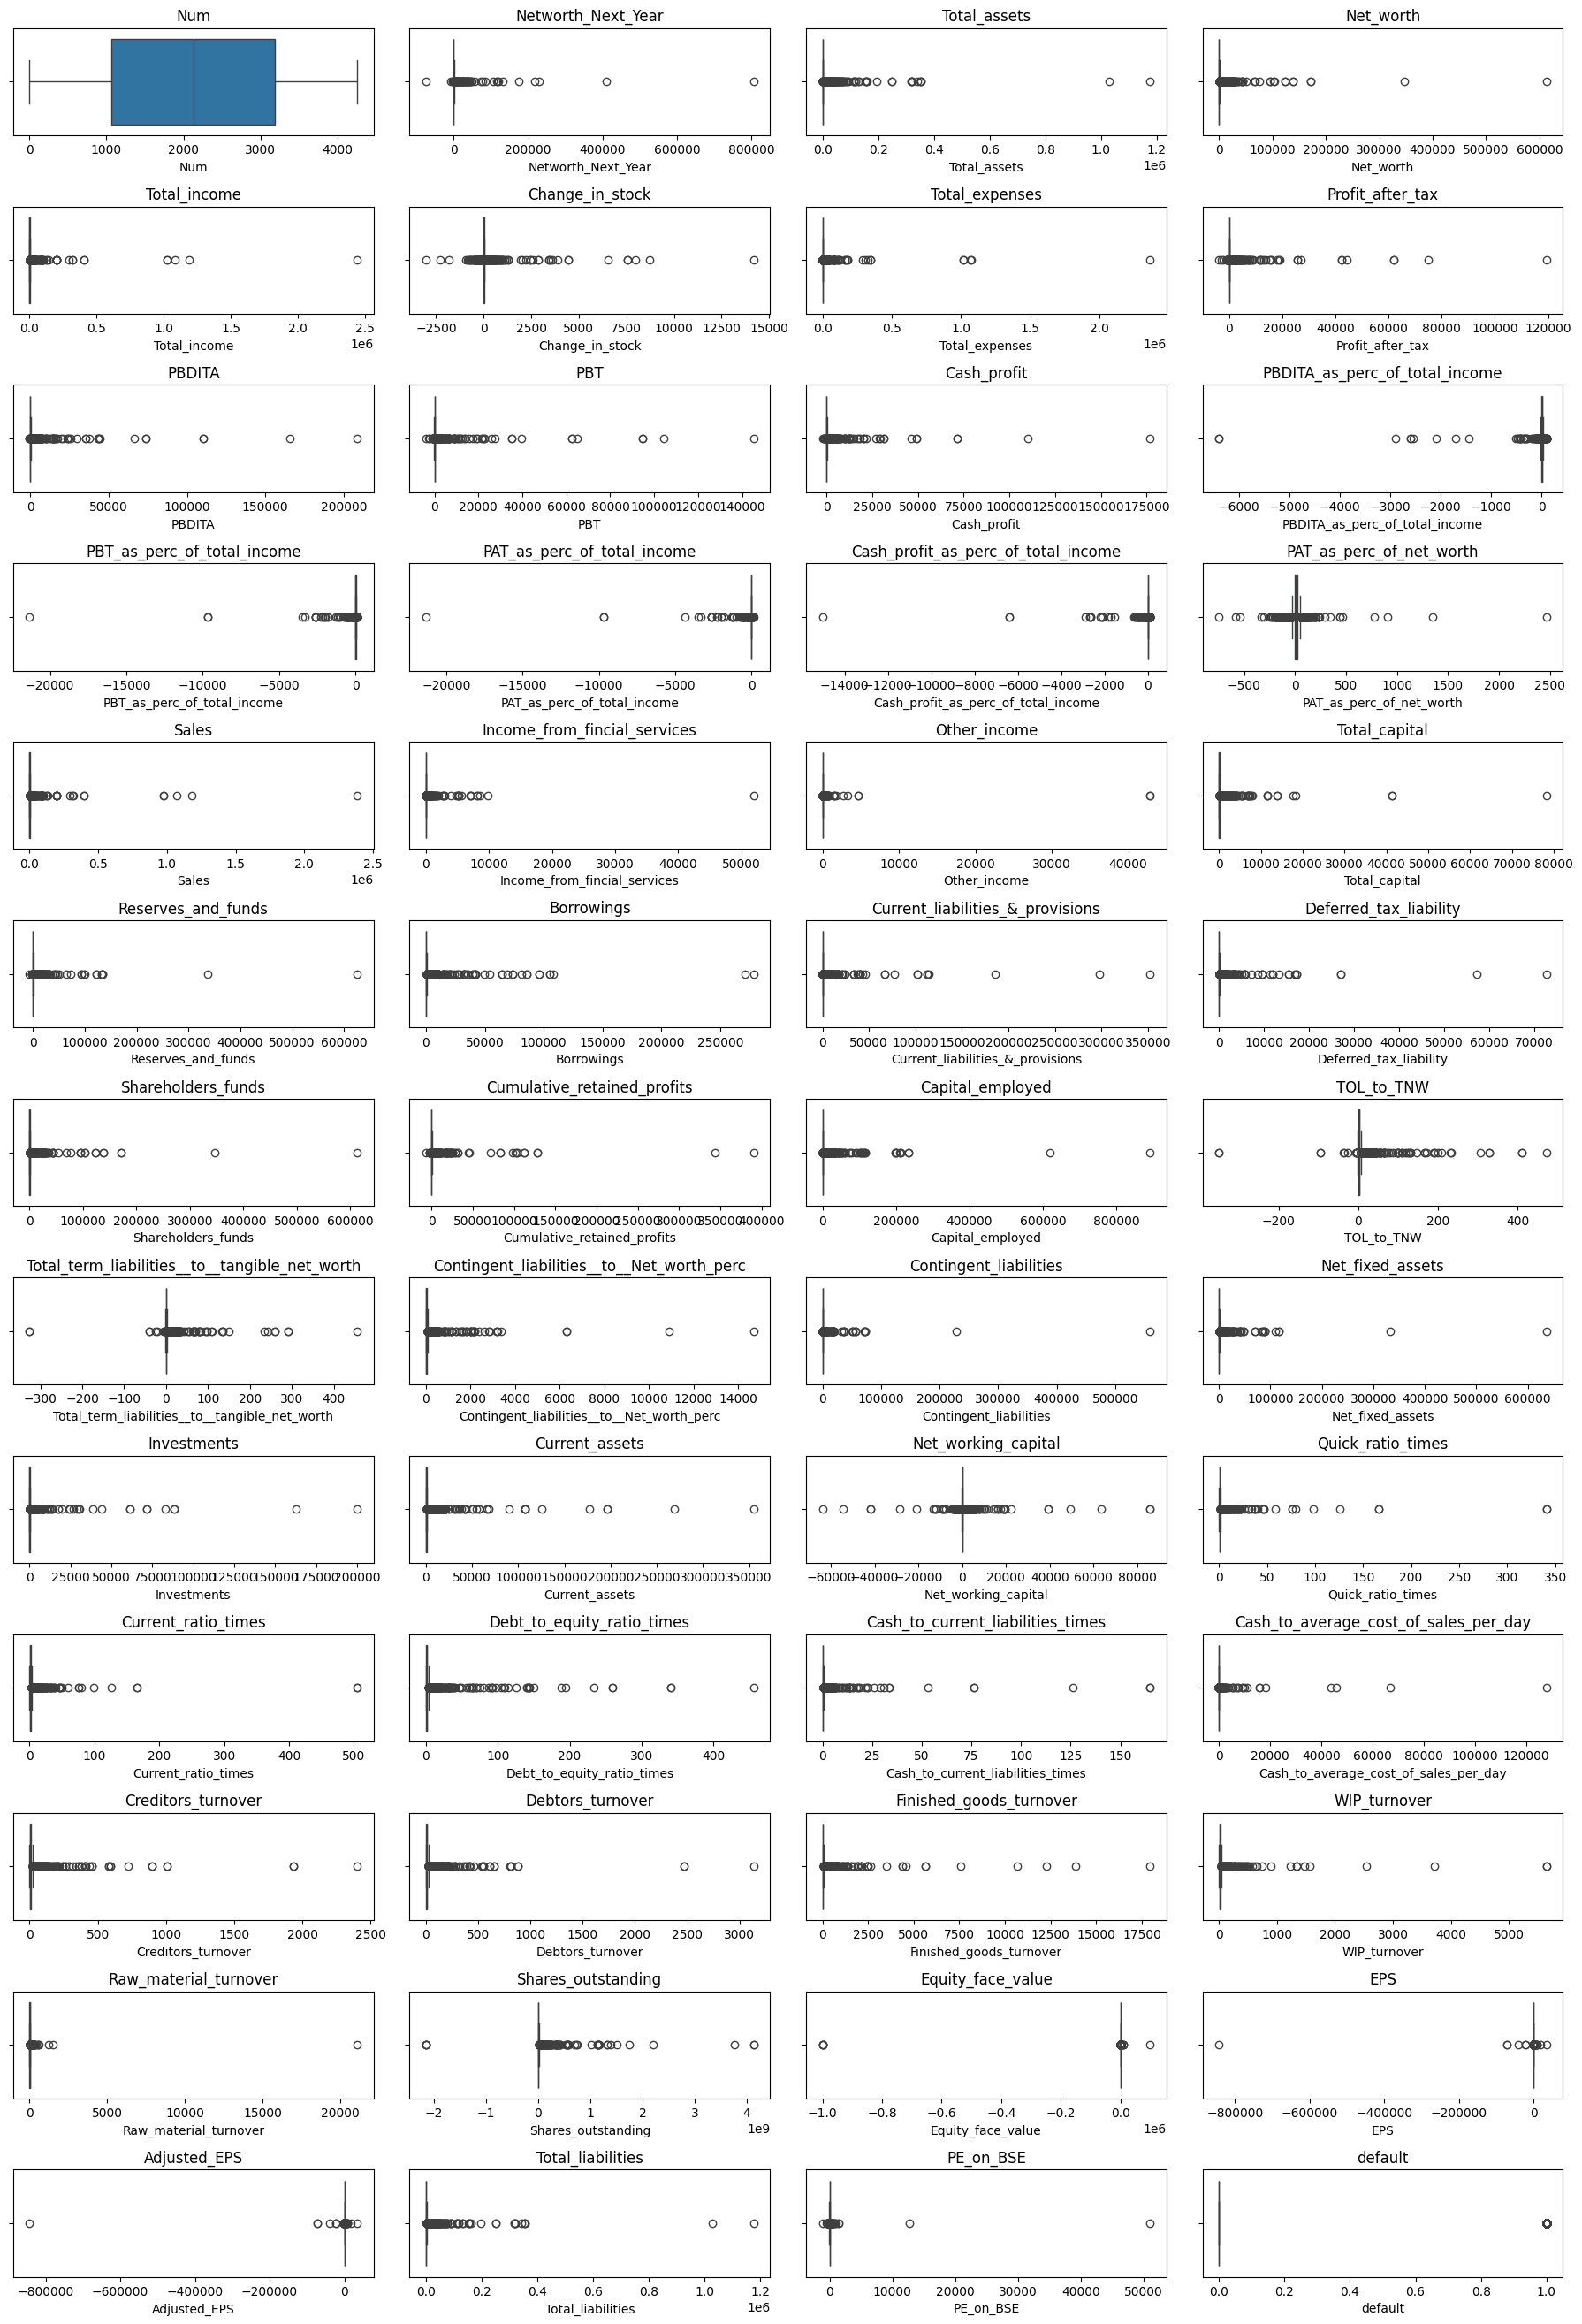

In [ ]:
# Get boxplots for all the numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(18, 30))

for i, variable in enumerate(numeric_columns):
    plt.subplot(15, 4, i + 1)
    sns.boxplot(data=df, x=variable)  ## Complete the code to get boxplots for all numerical columns
    plt.tight_layout()
    plt.title(variable)


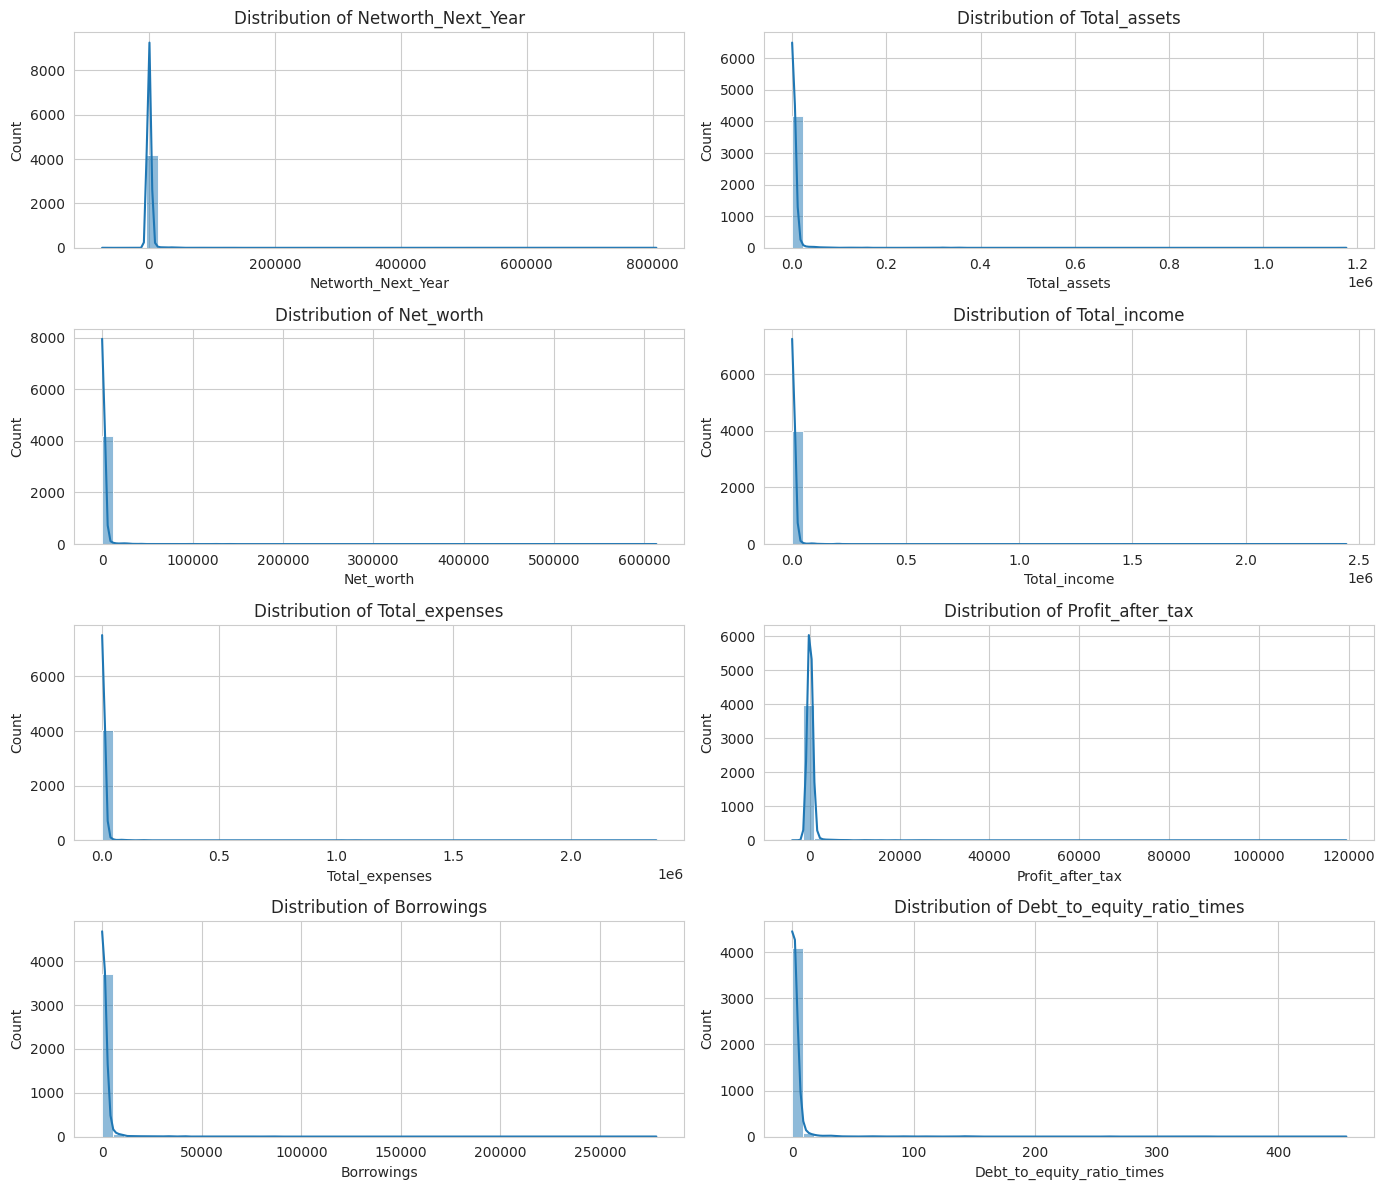

In [ ]:
# Set plot style
sns.set_style("whitegrid")

# Select a few key numerical columns for distribution plots
num_cols = ['Networth_Next_Year', 'Total_assets', 'Net_worth', 'Total_income',
            'Total_expenses', 'Profit_after_tax', 'Borrowings', 'Debt_to_equity_ratio_times']

# Plot histograms
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


## Bivariate Analysis

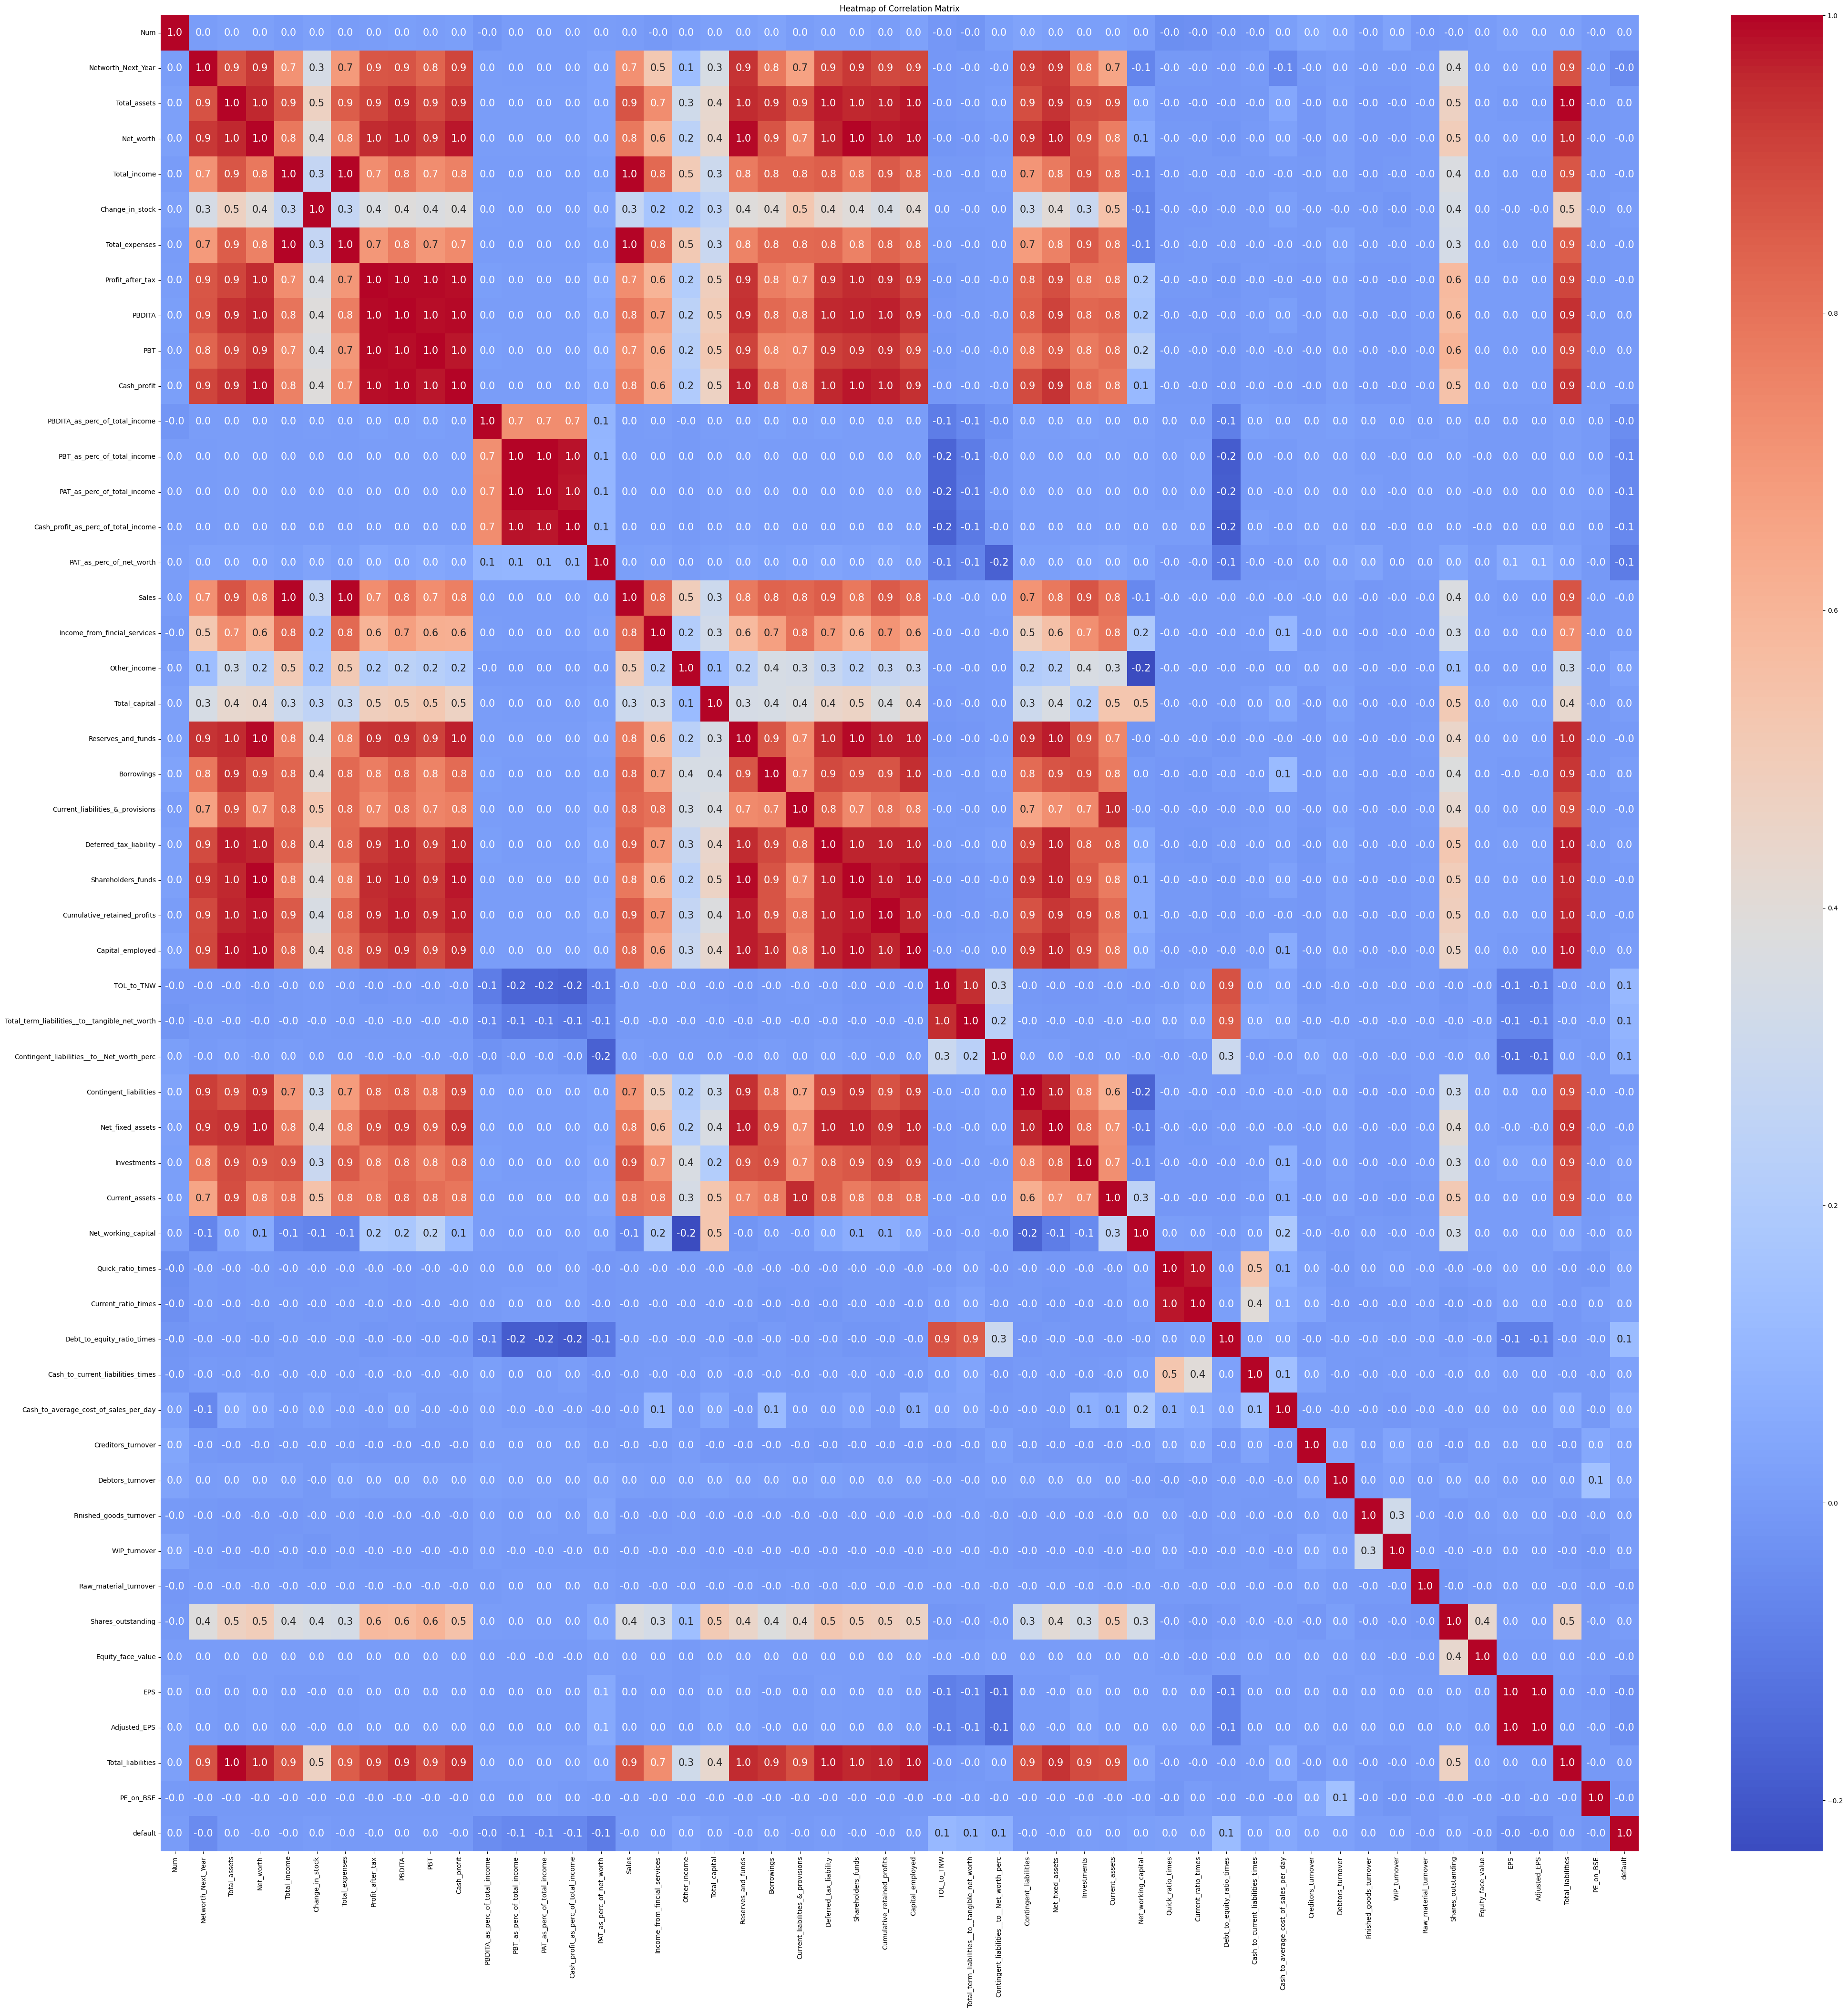

In [ ]:
# Calculate the correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Create a heatmap of the correlation matrix
plt.figure(figsize=(50, 50))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".1f", annot_kws={"size": 15})
plt.title('Heatmap of Correlation Matrix')
plt.show()

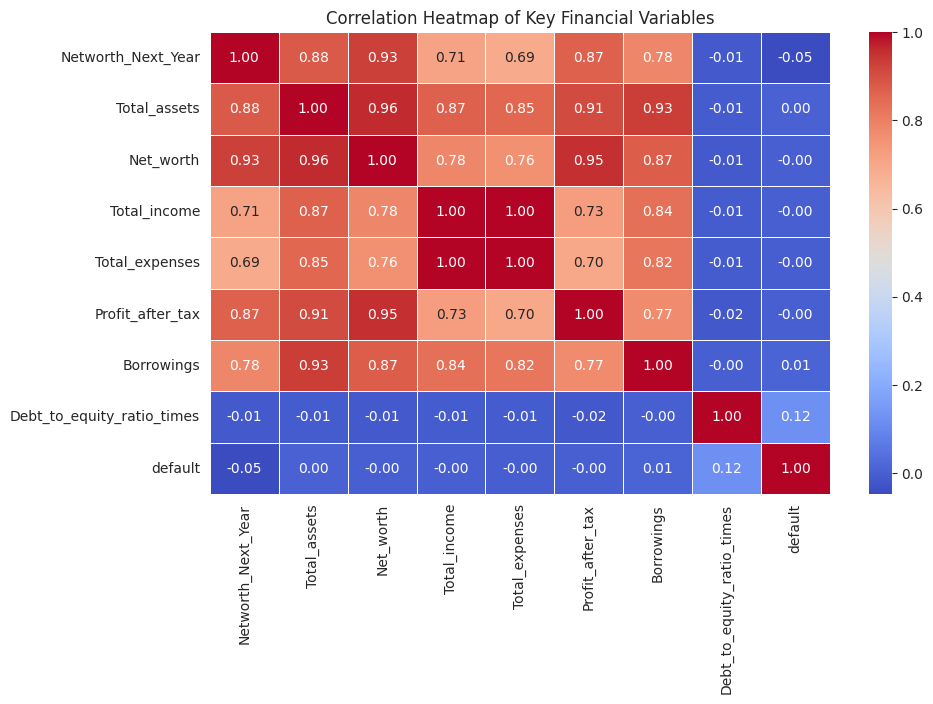

In [ ]:
# Compute correlation matrix for key financial variables
corr_matrix = df[num_cols + ['default']].corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Key Financial Variables")
plt.show()


# Data Preprocessing

## Outliers Check

In [ ]:
Company_X = df.drop('default', axis = 1)
Company_Y = df['default']

In [ ]:
Company_X

,Num,Networth_Next_Year,Total_assets,Net_worth,Total_income,Change_in_stock,Total_expenses,Profit_after_tax,PBDITA,PBT,...,Debtors_turnover,Finished_goods_turnover,WIP_turnover,Raw_material_turnover,Shares_outstanding,Equity_face_value,EPS,Adjusted_EPS,Total_liabilities,PE_on_BSE
0,1,395.30,827.60,336.50,534.10,13.50,508.70,38.90,124.40,64.60,...,5.65,3.99,3.37,14.87,8760056.00,10.00,4.44,4.44,827.60,NaN
1,2,36.20,67.70,24.30,137.90,-3.70,131.00,3.20,5.50,1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,67.70,NaN
2,3,84.00,238.40,78.90,331.20,-18.10,309.20,3.90,25.80,10.50,...,2.51,17.67,8.76,8.35,NaN,NaN,0.00,0.00,238.40,NaN
3,4,2041.40,6883.50,1443.30,8448.50,212.20,8482.40,178.30,418.40,185.10,...,1.91,18.14,18.62,11.11,10000000.00,10.00,17.60,17.60,6883.50,NaN
4,5,41.80,90.90,47.00,388.60,3.40,392.70,-0.70,7.20,-0.60,...,68.00,45.87,28.67,19.93,107315.00,100.00,-6.52,-6.52,90.90,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4251,4252,0.20,0.40,0.20,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,NaN,NaN,0.00,NaN,NaN,0.00,0.00,0.40,NaN
4252,4253,93.30,159.60,86.70,172.90,0.10,169.70,3.30,18.40,3.70,...,1.80,11.00,8.28,9.88,8162700.00,10.00,0.42,0.42,159.60,16.81
4253,4254,932.20,833.80,664.60,2314.70,32.10,2151.60,195.20,348.40,303.00,...,6.08,59.28,31.14,9.87,7479762.00,10.00,26.58,26.58,833.80,5.69
4254,4255,64.60,95.00,48.50,110.50,4.60,113.50,1.60,9.70,2.60,...,3.71,78.99,11.51,14.95,NaN,NaN,0.00,0.00,95.00,NaN


In [ ]:
Company_Y

,default
0,0
1,0
2,0
3,0
4,0
...,...
4251,0
4252,0
4253,0
4254,0


### Let's check the number of outliers per column

In [ ]:
# Let's check the number of outliers per column
Q1 = Company_X.quantile(0.25)
Q3 = Company_X.quantile(0.75)
IQR = Q3 - Q1
UL = Q3 + 1.5*IQR
LL = Q1 - 1.5*IQR

In [ ]:
((Company_X > UL) | (Company_X < LL)).sum()

,0
Num,0
Networth_Next_Year,624
Total_assets,585
Net_worth,595
Total_income,508
Change_in_stock,750
Total_expenses,518
Profit_after_tax,712
PBDITA,584
PBT,704


In [ ]:
Company_X[((Company_X > UL) | (Company_X < LL))]= np.nan

In [ ]:
Company_X.isnull().sum()

,0
Num,0
Networth_Next_Year,624
Total_assets,585
Net_worth,595
Total_income,739
Change_in_stock,1300
Total_expenses,683
Profit_after_tax,866
PBDITA,738
PBT,858


In [ ]:
Company_X.isnull().sum().sum()

43724

In [ ]:
Company_X = Company_X.drop(['Num', 'Networth_Next_Year', 'Equity_face_value'], axis = 1)

In [ ]:
Company_X.shape

(4256, 48)

In [ ]:
Company_sub1 = pd.concat([Company_X, Company_Y], axis =1 )

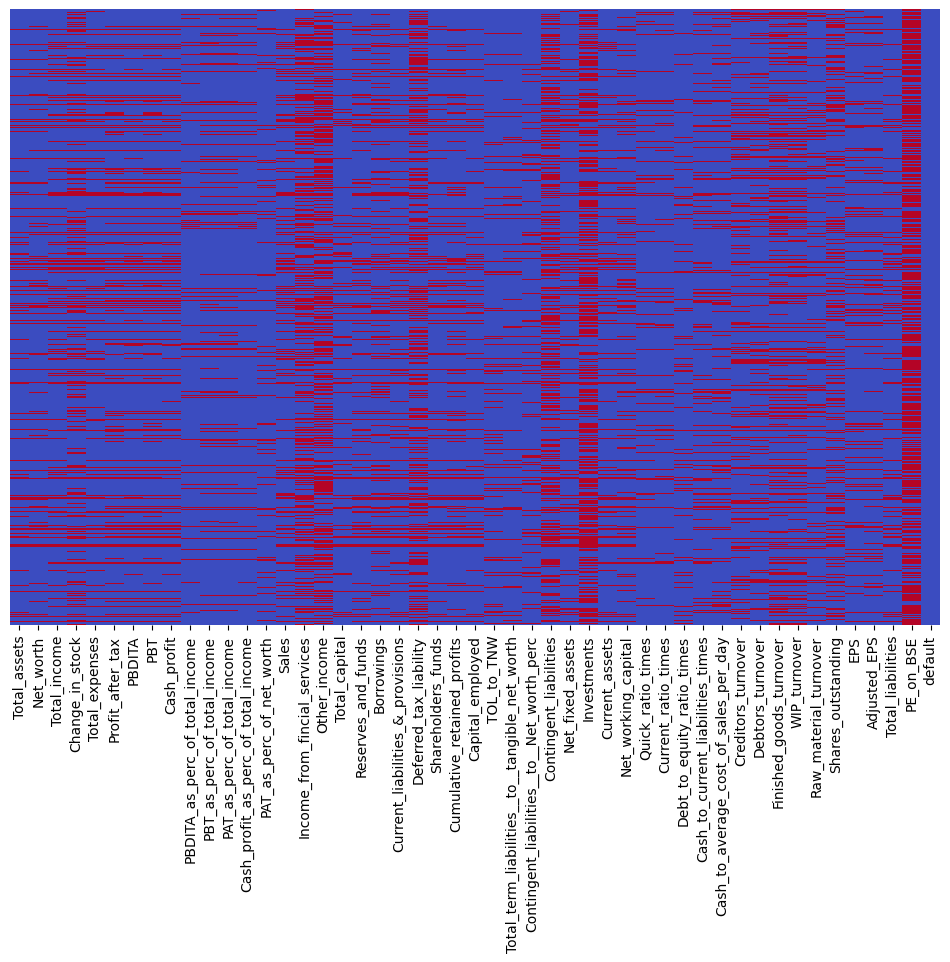

In [ ]:
# Let's visually inspect the missing values in our data
plt.figure(figsize = (12,8))
sns.heatmap(Company_sub1.isnull(), cbar = False, cmap = 'coolwarm', yticklabels = False)
plt.show()

### Inspecting total missing values by each row.

In [ ]:
# We should inspect total missing values by each row.
Company_sub1.isnull().sum(axis = 1)

,0
0,4
1,8
2,3
3,21
4,4
...,...
4251,24
4252,5
4253,8
4254,5


In [ ]:
Company_sub1_temp = Company_sub1[Company_sub1.isnull().sum(axis = 1) <= 5]

In [ ]:
Company_sub1_temp.shape

(1657, 49)

In [ ]:
Company_sub1_temp['default'].value_counts()

,count
default,
0,1367
1,290


In [ ]:
290/904

0.32079646017699115

If we consider availability of features for deciding the observations to be considered, we will end up losing more than 65% of the actual defaulters.

In [ ]:
Company_sub1['default'].value_counts()

,count
default,
0,3352
1,904


In [ ]:
Company_sub1.isnull().sum().sort_values(ascending = False)/Company_sub1.index.size

,0
PE_on_BSE,0.67
Investments,0.51
Other_income,0.46
Contingent_liabilities,0.42
Deferred_tax_liability,0.42
Income_from_fincial_services,0.38
Change_in_stock,0.31
Shares_outstanding,0.30
Finished_goods_turnover,0.30
WIP_turnover,0.27


 Dropping columns with more than 30% missing values

In [ ]:
Company_sub2 = Company_sub1.drop(['PE_on_BSE',
                             'Investments', 'Other_income', 'Contingent_liabilities',
                             'Deferred_tax_liability', 'Income_from_fincial_services',
                                  'Change_in_stock'],
                           axis = 1)

In [ ]:
Company_sub2.shape

(4256, 42)

Segregate the predictors and response

In [ ]:
predictors = Company_sub2.drop('default', axis = 1)
response = Company_sub2['default']

In [ ]:
# Scale the predictors
scaler = StandardScaler()
scaled_predictors = pd.DataFrame(scaler.fit_transform(predictors), columns = predictors.columns)

In [ ]:
Company_sub3 = pd.concat([scaled_predictors, response], axis = 1)

Imputing the remaining missing values

In [ ]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=10)

In [ ]:
Company_imputed = pd.DataFrame(imputer.fit_transform(Company_sub2), columns = Company_sub2.columns)

In [ ]:
Company_imputed.isnull().sum()

,0
Total_assets,0
Net_worth,0
Total_income,0
Total_expenses,0
Profit_after_tax,0
PBDITA,0
PBT,0
Cash_profit,0
PBDITA_as_perc_of_total_income,0
PBT_as_perc_of_total_income,0


Inspect possible correlations between independent variables

<Axes: >

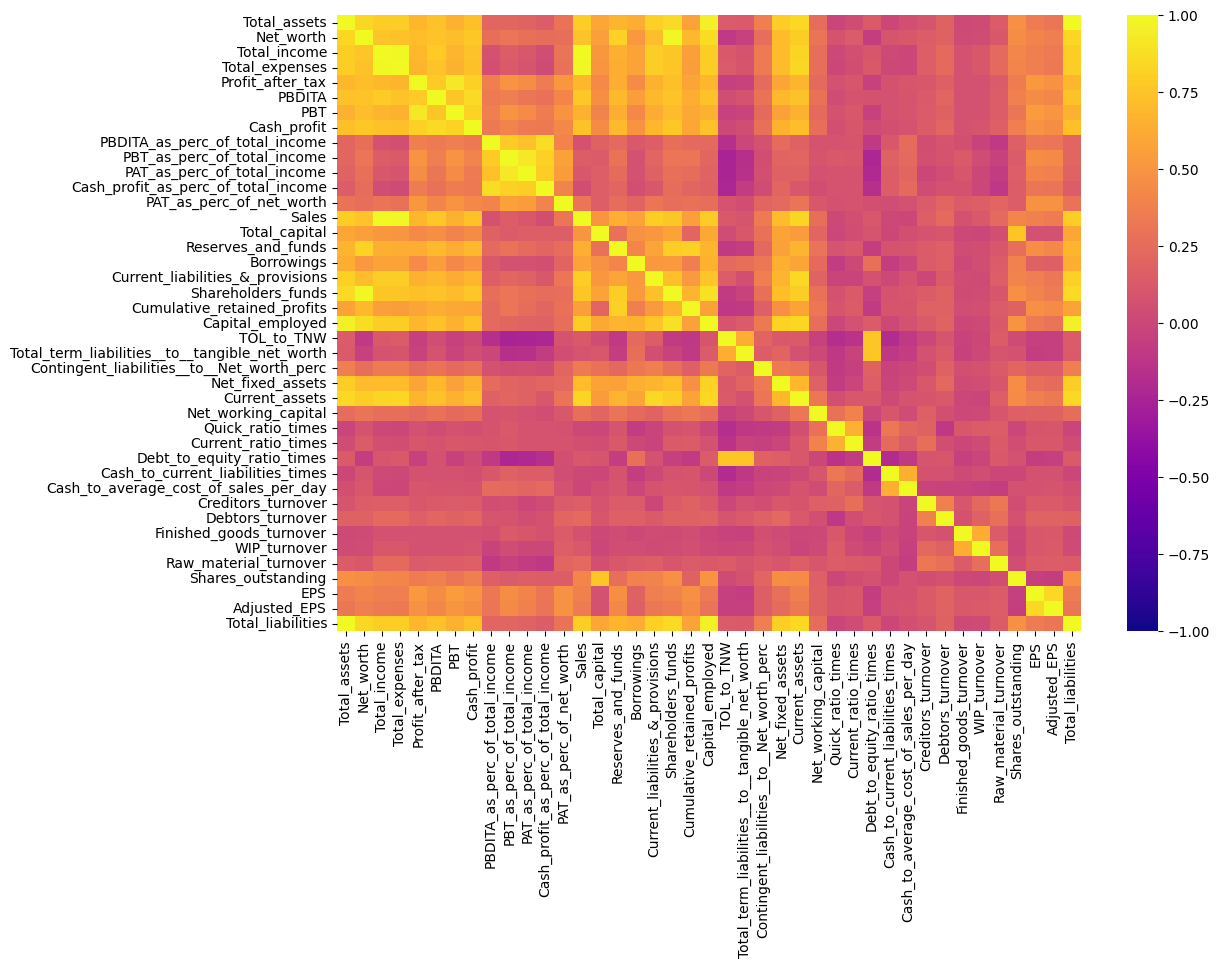

In [ ]:
plt.figure(figsize = (12,8))
cor_matrix = Company_imputed.drop('default', axis = 1).corr()
sns.heatmap(cor_matrix, cmap = 'plasma', vmin = -1, vmax= 1)

## Data Preparation for Modeling

In [ ]:
# Seperating target variable from the rest of the data
df_X = Company_imputed.drop(['default'], axis = 1)
df_y = Company_imputed['default']

In [ ]:
df_X.head()

,Total_assets,Net_worth,Total_income,Total_expenses,Profit_after_tax,PBDITA,PBT,Cash_profit,PBDITA_as_perc_of_total_income,PBT_as_perc_of_total_income,...,Cash_to_average_cost_of_sales_per_day,Creditors_turnover,Debtors_turnover,Finished_goods_turnover,WIP_turnover,Raw_material_turnover,Shares_outstanding,EPS,Adjusted_EPS,Total_liabilities
0,827.60,336.50,534.10,508.70,38.90,124.40,64.60,95.20,23.29,12.10,...,5.41,11.60,5.65,3.99,3.37,14.87,8760056.00,4.44,4.44,827.60
1,67.70,24.30,137.90,131.00,3.20,5.50,1.00,3.80,3.99,0.73,...,1.62,6.16,8.28,14.79,11.00,6.53,4460030.90,0.00,0.00,67.70
2,238.40,78.90,331.20,309.20,3.90,25.80,10.50,9.40,7.79,3.17,...,26.42,2.24,2.51,17.67,8.76,8.35,10179161.80,0.00,0.00,238.40
3,1751.40,594.76,2070.46,2144.28,73.67,70.67,93.63,178.00,4.95,2.19,...,15.93,3.48,1.91,18.14,18.62,11.11,10000000.00,17.60,17.60,1751.40
4,90.90,47.00,388.60,392.70,-0.70,7.20,-0.60,3.90,1.85,-0.15,...,0.85,21.67,6.59,45.87,28.67,19.93,107315.00,-6.52,-6.52,90.90


In [ ]:
#Splitting the data for training and testing
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.3, random_state=42, stratify = df_y)

In [ ]:
# checking the missing values
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


In [ ]:
X_train.shape

(2979, 41)

In [ ]:
X_test.shape

(1277, 41)

## Scaling the Data

In [ ]:
#Scaling of features is done to bring all the features to the same scale.
sc = StandardScaler()

X_train_scaled = pd.DataFrame(sc.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(sc.transform(X_test), columns=X_test.columns)

In [ ]:
X_train_scaled.head()

,Total_assets,Net_worth,Total_income,Total_expenses,Profit_after_tax,PBDITA,PBT,Cash_profit,PBDITA_as_perc_of_total_income,PBT_as_perc_of_total_income,...,Cash_to_average_cost_of_sales_per_day,Creditors_turnover,Debtors_turnover,Finished_goods_turnover,WIP_turnover,Raw_material_turnover,Shares_outstanding,EPS,Adjusted_EPS,Total_liabilities
0,-0.81,-0.72,-0.80,-0.81,-0.49,-0.65,-0.50,-0.56,1.05,1.29,...,-0.26,0.59,0.16,0.75,0.37,0.21,-0.60,-0.18,-0.01,-0.81
1,0.68,0.34,0.74,0.71,3.02,1.93,1.05,1.65,0.80,1.62,...,-0.70,-0.02,-0.28,0.76,0.66,-0.14,1.15,-0.67,-0.67,0.68
2,-0.47,-0.37,-0.58,-0.59,-0.26,-0.26,-0.14,-0.14,0.94,0.76,...,1.85,0.29,-0.12,0.42,0.38,-0.24,-0.44,-0.58,-0.55,-0.47
3,2.30,0.55,-0.57,-0.57,-0.41,0.93,-0.42,1.46,-0.56,-0.08,...,0.04,-1.40,-1.41,0.21,-0.42,-1.28,0.94,-0.66,-0.66,2.30
4,-0.26,-0.40,-0.12,-0.10,-0.39,-0.14,-0.35,-0.08,-0.28,-0.48,...,-0.93,2.29,0.06,2.10,3.06,0.22,-0.51,-0.08,0.12,-0.26


In [ ]:
X_test_scaled.head()

,Total_assets,Net_worth,Total_income,Total_expenses,Profit_after_tax,PBDITA,PBT,Cash_profit,PBDITA_as_perc_of_total_income,PBT_as_perc_of_total_income,...,Cash_to_average_cost_of_sales_per_day,Creditors_turnover,Debtors_turnover,Finished_goods_turnover,WIP_turnover,Raw_material_turnover,Shares_outstanding,EPS,Adjusted_EPS,Total_liabilities
0,-0.07,1.57,1.94,1.94,0.38,2.50,0.07,2.42,0.12,-0.64,...,0.37,1.06,-0.11,-0.78,-0.64,-0.70,1.11,-0.41,-0.32,-0.07
1,-0.86,-0.85,-0.86,-0.86,-0.71,-0.79,-0.71,-0.75,-1.01,-0.89,...,-1.01,-0.98,-0.42,-0.60,-0.08,0.28,-1.05,-0.66,-0.66,-0.86
2,-0.85,-0.89,-0.89,-0.89,-0.78,-0.83,-0.76,-0.80,-0.63,-0.40,...,0.39,-1.36,-1.45,-0.80,-0.08,-1.28,-1.03,-2.25,-2.78,-0.85
3,-0.85,-0.83,-0.88,-0.89,-0.71,-0.80,-0.71,-0.76,-0.45,-0.39,...,0.51,-0.55,-1.45,-1.25,-1.39,-1.28,0.35,-0.66,-0.66,-0.85
4,-0.60,-0.73,-0.27,-0.24,-0.55,-0.60,-0.49,-0.55,-0.97,-0.58,...,-0.39,0.68,0.12,-0.02,0.24,1.67,-0.98,1.01,1.56,-0.60


#Model Building

## Model Evaluation Criterion

*Metric of Choice*
-


In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification(model, predictors, target, threshold = 0.5):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    y_pred = model.predict(predictors)

    if len(list(set(y_pred))) != 2:
        y_prob_pred = model.predict(predictors)

        y_pred=[]
        for i in range(0,len(y_prob_pred)):
            if np.array(y_prob_pred)[i] > threshold:
                a=1
            else:
                a=0
            y_pred.append(a)
    else:
        pass

    acc = accuracy_score(target, y_pred)  # to compute Accuracy
    recall = recall_score(target, y_pred)  # to compute Recall
    precision = precision_score(target, y_pred)  # to compute Precision
    f1 = f1_score(target, y_pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def model_confusion_matrix(model, predictors, target, threshold = 0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    if len(list(set(y_pred))) != 2:
        y_prob_pred = model.predict(predictors)

        y_pred=[]
        for i in range(0,len(y_prob_pred)):
            if np.array(y_prob_pred)[i] > threshold:
                a=1
            else:
                a=0
            y_pred.append(a)
    else:
        pass

    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## Logistic Regression

In [ ]:
# Adding constant to data for Logistic Regression
X_train_with_intercept = SM.add_constant(X_train_scaled)
X_test_with_intercept = SM.add_constant(X_test_scaled)
X_train_with_intercept.head()

,const,Total_assets,Net_worth,Total_income,Total_expenses,Profit_after_tax,PBDITA,PBT,Cash_profit,PBDITA_as_perc_of_total_income,...,Cash_to_average_cost_of_sales_per_day,Creditors_turnover,Debtors_turnover,Finished_goods_turnover,WIP_turnover,Raw_material_turnover,Shares_outstanding,EPS,Adjusted_EPS,Total_liabilities
0,1.00,-0.81,-0.72,-0.80,-0.81,-0.49,-0.65,-0.50,-0.56,1.05,...,-0.26,0.59,0.16,0.75,0.37,0.21,-0.60,-0.18,-0.01,-0.81
1,1.00,0.68,0.34,0.74,0.71,3.02,1.93,1.05,1.65,0.80,...,-0.70,-0.02,-0.28,0.76,0.66,-0.14,1.15,-0.67,-0.67,0.68
2,1.00,-0.47,-0.37,-0.58,-0.59,-0.26,-0.26,-0.14,-0.14,0.94,...,1.85,0.29,-0.12,0.42,0.38,-0.24,-0.44,-0.58,-0.55,-0.47
3,1.00,2.30,0.55,-0.57,-0.57,-0.41,0.93,-0.42,1.46,-0.56,...,0.04,-1.40,-1.41,0.21,-0.42,-1.28,0.94,-0.66,-0.66,2.30
4,1.00,-0.26,-0.40,-0.12,-0.10,-0.39,-0.14,-0.35,-0.08,-0.28,...,-0.93,2.29,0.06,2.10,3.06,0.22,-0.51,-0.08,0.12,-0.26


In [ ]:
 y_train.reset_index(inplace = True, drop = True)

In [ ]:
X_train_scaled.shape

(2979, 41)

In [ ]:
X_train_with_intercept.shape

(2979, 42)

In [ ]:
# Fitting the Logistic Regression Model with regularization
LogisticReg = SM.Logit(y_train, X_train_with_intercept).fit()
print(LogisticReg.summary())


Optimization terminated successfully.
         Current function value: 0.504625
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 2979
Model:                          Logit   Df Residuals:                     2938
Method:                           MLE   Df Model:                           40
Date:                Sun, 16 Mar 2025   Pseudo R-squ.:                 0.02438
Time:                        17:06:23   Log-Likelihood:                -1503.3
converged:                       True   LL-Null:                       -1540.8
Covariance Type:            nonrobust   LLR p-value:                 0.0006436
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
const                               

### Logistic Regression Model - Training Performance

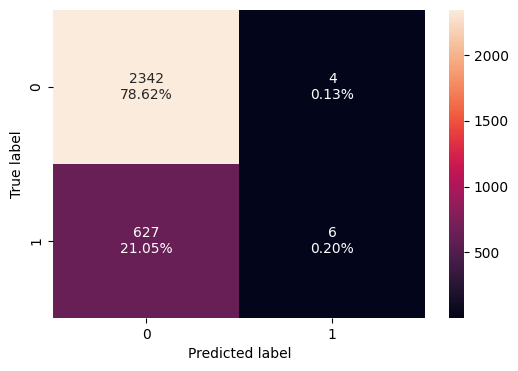

In [ ]:
model_confusion_matrix(LogisticReg, X_train_with_intercept, y_train)

In [ ]:
logistic_regression_perf_train = model_performance_classification(LogisticReg, X_train_with_intercept, y_train)
logistic_regression_perf_train

,Accuracy,Recall,Precision,F1
0,0.79,0.01,0.60,0.02


### Logistic Regression Model - Test Performance

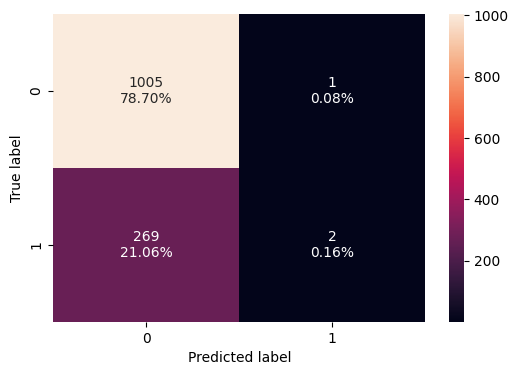

In [ ]:
model_confusion_matrix(LogisticReg, X_test_with_intercept, y_test)  ## Complete the code to create confusion matrix for test data

In [ ]:
logistic_regression_perf_test = model_performance_classification(LogisticReg, X_test_with_intercept, y_test)  ## Complete the code to check performance on test data
logistic_regression_perf_test

,Accuracy,Recall,Precision,F1
0,0.79,0.01,0.67,0.01


## Random Forest

In [ ]:
rf_classifier = RandomForestClassifier(random_state=42)  ## Complete the code to define random forest with random state = 42
rf_model = rf_classifier.fit(X_train_scaled, y_train) ## Complete the code to fit random forest on the train data

### Random Forest Model - Training Performance

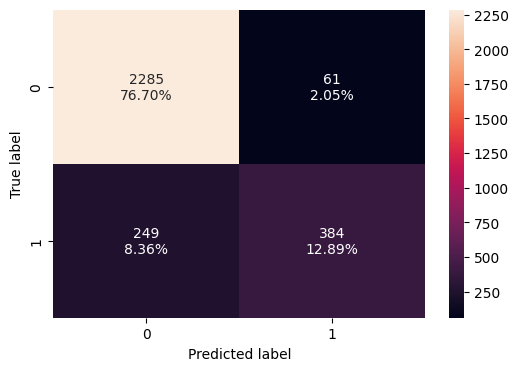

In [ ]:
model_confusion_matrix(rf_model, X_train_scaled, y_train)

In [ ]:
random_forest_perf_train = model_performance_classification(rf_model, X_train_scaled, y_train)
random_forest_perf_train

,Accuracy,Recall,Precision,F1
0,0.90,0.61,0.86,0.71


### Random Forest Model - Test Performance

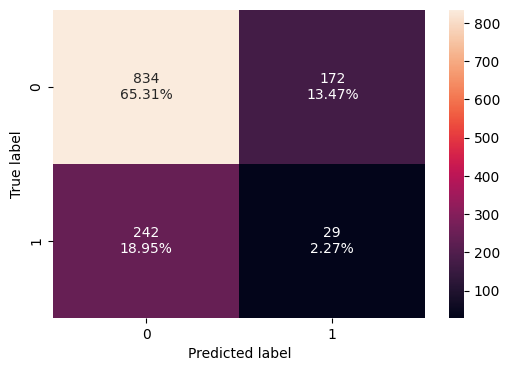

In [ ]:
model_confusion_matrix(rf_model, X_test_scaled, y_test)  ## Complete the code to create confusion matrix for test data

In [ ]:
random_forest_perf_test = model_performance_classification(rf_model, X_test_scaled, y_test)  ## Complete the code to check performance on test data
random_forest_perf_test

,Accuracy,Recall,Precision,F1
0,0.68,0.11,0.14,0.12


# Model Performance Improvement

## Model Performance Improvement - Logistic Regression

In [ ]:
def calculate_vif(idf):
    """
    Calculate Variance Inflation Factor (VIF) for each variable in a DataFrame.

    Parameters:
    df (DataFrame): Input DataFrame containing numerical variables.

    Returns:
    vif_df (DataFrame): DataFrame containing variable names and their corresponding VIF values.
    """
    variables = idf.values
    vif_df = pd.DataFrame()
    vif_df["Variable"] = idf.columns
    vif_df["VIF"] = [variance_inflation_factor(variables, i) for i in range(idf.shape[1])]
    return vif_df

In [ ]:
# Call the function to calculate VIF
vif_result = calculate_vif(X_train_scaled)  ## Complete the code to calculate VIF for the scaled X_train data

print("Variance Inflation Factors:")
vif_result

Variance Inflation Factors:


,Variable,VIF
0,Total_assets,inf
1,Net_worth,39.03
2,Total_income,89.03
3,Total_expenses,52.13
4,Profit_after_tax,8.54
5,PBDITA,5.52
6,PBT,8.56
7,Cash_profit,6.05
8,PBDITA_as_perc_of_total_income,4.85
9,PBT_as_perc_of_total_income,9.29


In [ ]:
# Sort VIF values in descending order
vif_result_sorted = vif_result.sort_values(by='VIF', ascending=False)

print("Variance Inflation Factors (Sorted):")
vif_result_sorted


Variance Inflation Factors (Sorted):


,Variable,VIF
0,Total_assets,inf
40,Total_liabilities,inf
13,Sales,92.34
2,Total_income,89.03
3,Total_expenses,52.13
18,Shareholders_funds,43.22
1,Net_worth,39.03
20,Capital_employed,19.73
9,PBT_as_perc_of_total_income,9.29
6,PBT,8.56


In [ ]:
high_vif_columns = []
for i, row in vif_result.iterrows():
    if row['VIF'] >= 5:
        high_vif_columns.append(row['Variable'])
high_vif_columns

['Total_assets',
 'Net_worth',
 'Total_income',
 'Total_expenses',
 'Profit_after_tax',
 'PBDITA',
 'PBT',
 'Cash_profit',
 'PBT_as_perc_of_total_income',
 'PAT_as_perc_of_total_income',
 'Cash_profit_as_perc_of_total_income',
 'Sales',
 'Reserves_and_funds',
 'Current_liabilities_&_provisions',
 'Shareholders_funds',
 'Capital_employed',
 'Current_assets',
 'Total_liabilities']

In [ ]:
# Dropping columns with VIF > 5
X_train_scaled.drop(columns = high_vif_columns, axis=1, inplace=True)
X_test_scaled.drop(columns = high_vif_columns, axis=1, inplace=True)

In [ ]:
X_train_scaled.shape

(2979, 23)

In [ ]:
X_test_scaled.shape

(1277, 23)

In [ ]:
X_train_new_with_intercept = SM.add_constant(X_train_scaled)
X_test_new_with_intercept = SM.add_constant(X_test_scaled)

In [ ]:
# Retraining Logistic Regression Model with new data
LogisticReg_improved = SM.Logit(y_train, X_train_new_with_intercept).fit() ## Complete the code to fir Logistic Regression Model on new train data with intercept
print(LogisticReg_improved.summary())

Optimization terminated successfully.
         Current function value: 0.507474
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 2979
Model:                          Logit   Df Residuals:                     2955
Method:                           MLE   Df Model:                           23
Date:                Sun, 16 Mar 2025   Pseudo R-squ.:                 0.01887
Time:                        17:06:37   Log-Likelihood:                -1511.8
converged:                       True   LL-Null:                       -1540.8
Covariance Type:            nonrobust   LLR p-value:                 7.049e-05
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
const                               

In [ ]:
# Finding Optimal Threshold value
logit_y_pred = LogisticReg_improved.predict(X_train_new_with_intercept)
fpr, tpr, thresholds = roc_curve(y_train, logit_y_pred)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_logit = round(thresholds[optimal_idx], 3)
optimal_threshold_logit

0.244

In [ ]:
# prompt: roc_auc = _______(y_train, logit_y_pred)  ## Complete the code to get roc_auc score

roc_auc = roc_auc_score(y_train, logit_y_pred)


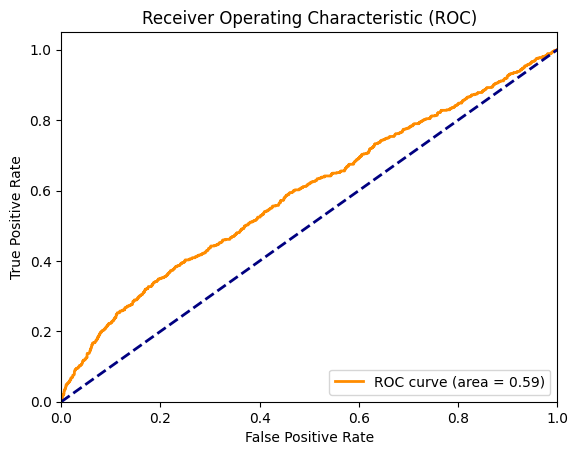

In [ ]:
roc_auc = roc_auc_score(y_train, logit_y_pred)  ## Complete the code to get roc_auc score
# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

### Logistic Regression Performance - Training Set

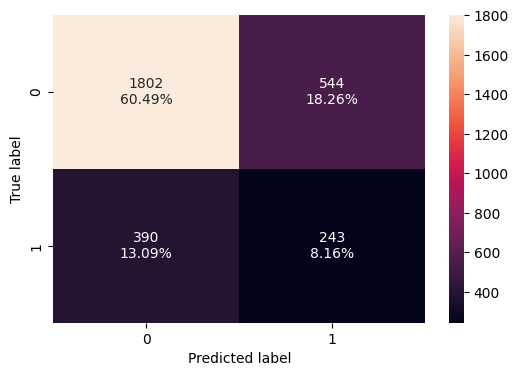

In [ ]:
model_confusion_matrix(LogisticReg_improved, X_train_new_with_intercept, y_train, optimal_threshold_logit)

In [ ]:
logistic_regression_tuned_perf_train = model_performance_classification(
    LogisticReg_improved, X_train_new_with_intercept, y_train, optimal_threshold_logit
)
logistic_regression_tuned_perf_train

,Accuracy,Recall,Precision,F1
0,0.69,0.38,0.31,0.34


### Logistic Regression Performance - Test Set

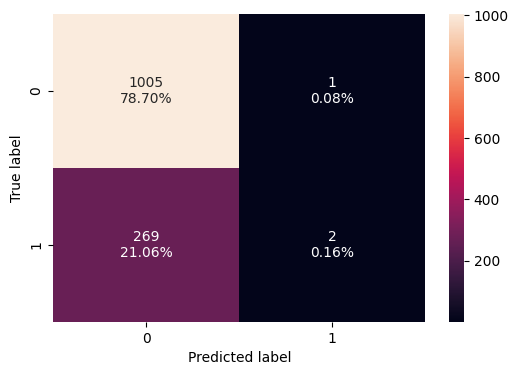

In [ ]:
model_confusion_matrix(LogisticReg, X_test_with_intercept, y_test) ## Complete the code to create confusion matrix for test data

In [ ]:
logistic_regression_tuned_perf_test = model_performance_classification(LogisticReg, X_test_with_intercept, y_test)  ## Complete the code to check performance on test data
logistic_regression_tuned_perf_test

,Accuracy,Recall,Precision,F1
0,0.79,0.01,0.67,0.01


## Model Performance Improvement - Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Optimized parameter grid
param_dist = {
    'n_estimators': [100, 200],  # Reduce number of trees for faster training
    'max_depth': [5, 7],  # Reduce options
    'min_samples_split': [2, 5],  # Reduce combinations
    'min_samples_leaf': [5, 6],  # Reduce combinations
}

rf_classifier = RandomForestClassifier(class_weight='balanced', random_state=42)

# Use RandomizedSearchCV for faster execution
random_search = RandomizedSearchCV(
    estimator=rf_classifier,
    param_distributions=param_dist,
    n_iter=10,  # Randomly test 10 combinations instead of exhaustive search
    cv=3,  # Reduce cross-validation folds for speed
    scoring='recall',
    n_jobs=-1,
    verbose=1,  # Show progress
    random_state=42
)

# Train the model
random_search.fit(X_train_scaled, y_train)

# Display best parameters
print("Best parameters:", random_search.best_params_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_depth': 5}


In [ ]:
# Access the best trained RandomForestClassifier model
best_rf_classifier = random_search.best_estimator_

# Get parameters of the best model
params_used = best_rf_classifier.get_params()

# Print the parameters
print("Parameters used in the Random Forest Classifier:")
for param_name, param_value in params_used.items():
    print(f"{param_name}: {param_value}")


Parameters used in the Random Forest Classifier:
bootstrap: True
ccp_alpha: 0.0
class_weight: balanced
criterion: gini
max_depth: 5
max_features: sqrt
max_leaf_nodes: None
max_samples: None
min_impurity_decrease: 0.0
min_samples_leaf: 5
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 100
n_jobs: None
oob_score: False
random_state: 42
verbose: 0
warm_start: False


### Random Forest Performance - Training Set

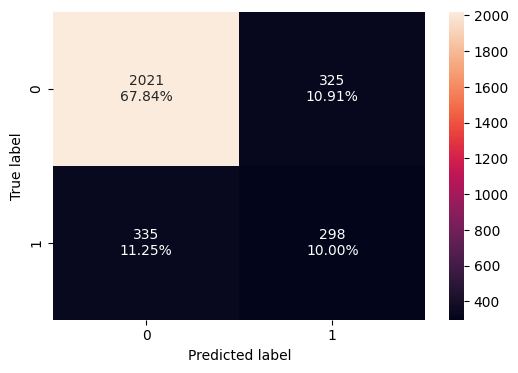

In [ ]:
model_confusion_matrix(best_rf_classifier, X_train_scaled, y_train)

In [ ]:
random_forest_tuned_perf_train = model_performance_classification(best_rf_classifier, X_train_scaled, y_train)
random_forest_tuned_perf_train

,Accuracy,Recall,Precision,F1
0,0.78,0.47,0.48,0.47


### Random Forest Performance - Test Set

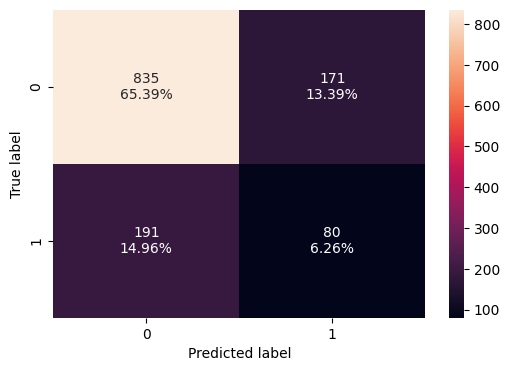

In [ ]:
model_confusion_matrix(best_rf_classifier, X_test_scaled, y_test)  ## Complete the code to create confusion matrix for test data

In [ ]:
random_forest_tuned_perf_test = model_performance_classification(best_rf_classifier, X_test_scaled, y_test)
random_forest_tuned_perf_test

,Accuracy,Recall,Precision,F1
0,0.72,0.30,0.32,0.31


# Model Comparison and Final Model Selection

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        logistic_regression_perf_train.T,
        logistic_regression_tuned_perf_train.T,
        random_forest_perf_train.T,
        random_forest_tuned_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression",
    "Tuned Logistic Regression",
    "Random Forest",
    "Tuned Random Forest",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Regression,Tuned Logistic Regression,Random Forest,Tuned Random Forest
Accuracy,0.79,0.69,0.90,0.78
Recall,0.01,0.38,0.61,0.47
Precision,0.60,0.31,0.86,0.48
F1,0.02,0.34,0.71,0.47


In [ ]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        logistic_regression_perf_test.T,
        logistic_regression_tuned_perf_test.T,
        random_forest_perf_test.T,
        random_forest_tuned_perf_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Logistic Regression",
    "Tuned Logistic Regression",
    "Random Forest",
    "Tuned Random Forest",
]
print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Logistic Regression,Tuned Logistic Regression,Random Forest,Tuned Random Forest
Accuracy,0.79,0.79,0.68,0.72
Recall,0.01,0.01,0.11,0.30
Precision,0.67,0.67,0.14,0.32
F1,0.01,0.01,0.12,0.31


In [ ]:
feature_names = X_train.columns
importances = best_rf_classifier.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(20, 20))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

# Conclusions and Recommendations

Strengthening Financial Risk Management:

Companies with high debt-to-equity ratios should focus on reducing liabilities through optimized capital structuring.

Regular liquidity assessments (current and quick ratios) should be conducted to prevent cash flow shortages.



Creditworthiness-Based Investment Decisions:

Investors should prioritize businesses with strong profitability indicators (PBDITA, PBT, and PAT margins).

Avoid investments in companies with persistent negative net worth trends.



Debt Restructuring for High-Risk Companies:

Businesses at risk of default should consider alternative financing options (e.g., equity financing vs. excessive debt reliance).

Establish structured debt repayment plans to enhance financial stability.



Automation of Financial Monitoring Systems:

Implement AI-driven early warning systems to detect signs of financial distress.

Continuous tracking of debt management practices to ensure timely corrective actions.


___

- By Nabankur Ray
[PGP-DSBA]

# **Problem Statement - Part B**

## Context

Investors face market risk, arising from asset price fluctuations due to economic events, geopolitical developments, and investor sentiment changes. Understanding and analyzing this risk is crucial for informed decision-making and optimizing investment strategies.

## Objective

The objective of this analysis is to conduct Market Risk Analysis on a portfolio of Indian stocks using Python. It uses historical stock price data to understand market volatility and riskiness. Using statistical measures like mean and standard deviation, investors gain a deeper understanding of individual stocks' performance and portfolio variability.

Through this analysis, investors can aim to achieve the following objectives:

1. Risk Assessment: Analyze the historical volatility of individual stocks and the overall portfolio.
2. Portfolio Optimization: Use Market Risk Analysis insights to enhance risk-adjusted returns.
3. Performance Evaluation: Assess portfolio management strategies' effectiveness in mitigating market risk.
4. Portfolio Performance Monitoring: Monitor portfolio performance over time and adjust as market conditions and risk preferences change.

## Data Dictionary

The dataset contains weekly stock price data for 5 Indian stocks over an 8-year period. The dataset enables us to analyze the historical performance of individual stocks and the overall market dynamics.

# Importing necessary Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

# Loading the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
df = pd.read_csv('/content/drive/My Drive/Market_Risk_Data.csv')
df.head()

Mounted at /content/drive/


,Date,ITC Limited,Bharti Airtel,Tata Motors,DLF Limited,Yes Bank
0,28-03-2016,217,316,386,114,173
1,04-04-2016,218,302,386,121,171
2,11-04-2016,215,308,374,120,171
3,18-04-2016,223,320,408,122,172
4,25-04-2016,214,319,418,122,175


# Overview of the Dataset

In [ ]:
# View the dimension of the data
df.shape

(418, 6)

* There are **418 rows** and **6 Columns** are present in the given datasets.

In [ ]:
# checking the column names and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           418 non-null    object
 1   ITC Limited    418 non-null    int64 
 2   Bharti Airtel  418 non-null    int64 
 3   Tata Motors    418 non-null    int64 
 4   DLF Limited    418 non-null    int64 
 5   Yes Bank       418 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 19.7+ KB


* It can be observed that no columns have less entries (less than 418 rows) which indicates that there are no missing values in the given dataset.

* There are attributes of different types (int, object) in the given dataset.

* There are 5 numerical columns in the data, 1 object Column(Date), which need to be converted to DateTime format.


In [ ]:
# checking for duplicate values
df.duplicated().sum()

0

In [ ]:
# checking for missing values in the data
df.isnull().sum()

,0
Date,0
ITC Limited,0
Bharti Airtel,0
Tata Motors,0
DLF Limited,0
Yes Bank,0


• There is no missing or null values.

• There is no duplicate values.

In [ ]:
# Statistical summary of the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ITC Limited,418.0,278.964115,75.114405,156.0,224.25,265.5,304.00,493.0
Bharti Airtel,418.0,528.260766,226.507879,261.0,334.00,478.0,706.75,1236.0
Tata Motors,418.0,368.617225,182.024419,65.0,186.00,399.5,466.00,1035.0
DLF Limited,418.0,276.827751,156.280781,110.0,166.25,213.0,360.50,928.0
Yes Bank,418.0,124.442584,130.090884,11.0,16.00,30.0,249.75,397.0


Stock Price Range & Central Tendency:

* Bharti Airtel has the highest average stock price (₹528.26), followed by Tata Motors (₹368.62), ITC Limited (₹278.96), DLF Limited (₹276.83), and Yes Bank (₹124.44).
* Yes Bank has the lowest median stock price (₹30), indicating a significant decline compared to others.

Volatility & Risk Assessment:

* Bharti Airtel (₹226.51) and Tata Motors (₹182.02) exhibit the highest standard deviation, indicating greater price fluctuations.
* Yes Bank has the highest price volatility relative to its mean (high standard deviation compared to its lower stock value).
* ITC Limited and DLF Limited show moderate fluctuations, making them relatively stable investments.

Minimum & Maximum Stock Prices:

* Bharti Airtel reached the highest maximum stock price (₹1236), while Yes Bank had the lowest recorded price (₹11).
* Tata Motors and DLF Limited show significant growth potential, given their high max values (₹1035 & ₹928, respectively).

In [ ]:
# Convert 'Date' column from object to datetimeobject to DateTime
df['Date']  = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           418 non-null    datetime64[ns]
 1   ITC Limited    418 non-null    int64         
 2   Bharti Airtel  418 non-null    int64         
 3   Tata Motors    418 non-null    int64         
 4   DLF Limited    418 non-null    int64         
 5   Yes Bank       418 non-null    int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 19.7 KB


In [ ]:
df.head()

,Date,ITC Limited,Bharti Airtel,Tata Motors,DLF Limited,Yes Bank
0,2016-03-28,217,316,386,114,173
1,2016-04-04,218,302,386,121,171
2,2016-04-11,215,308,374,120,171
3,2016-04-18,223,320,408,122,172
4,2016-04-25,214,319,418,122,175


# Stock Price Analysis

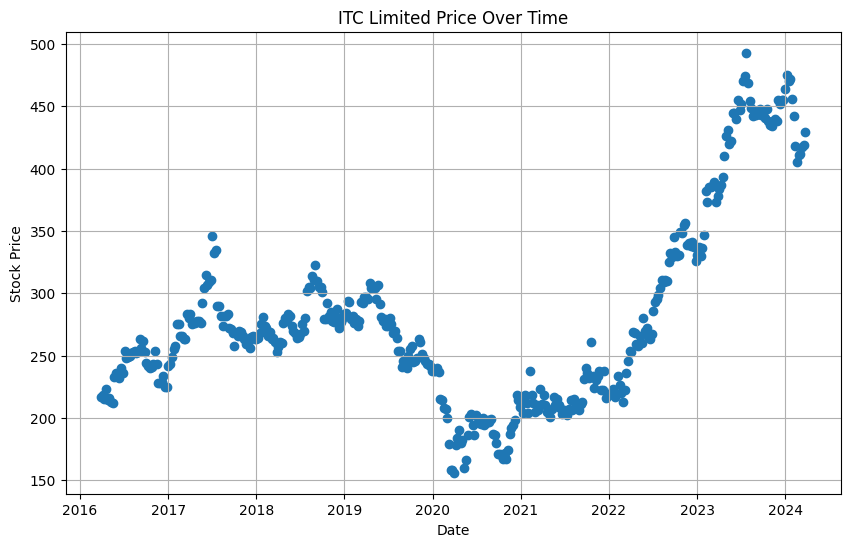

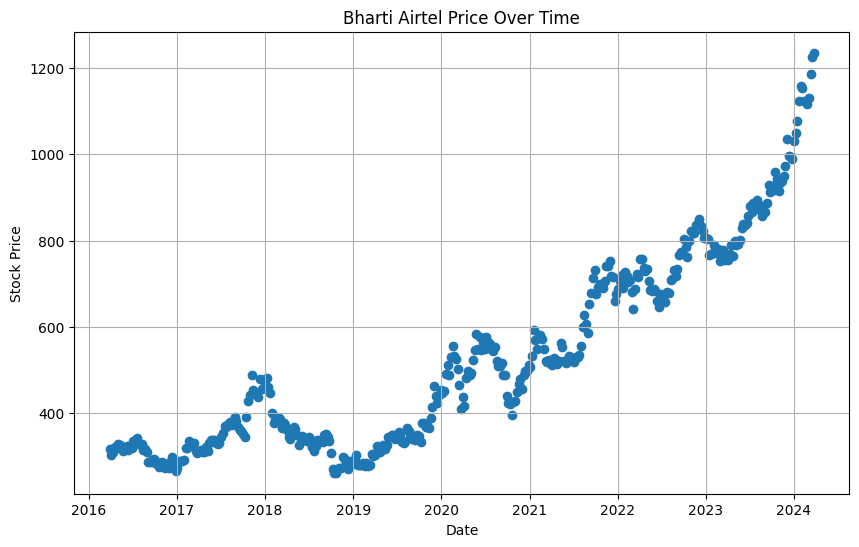

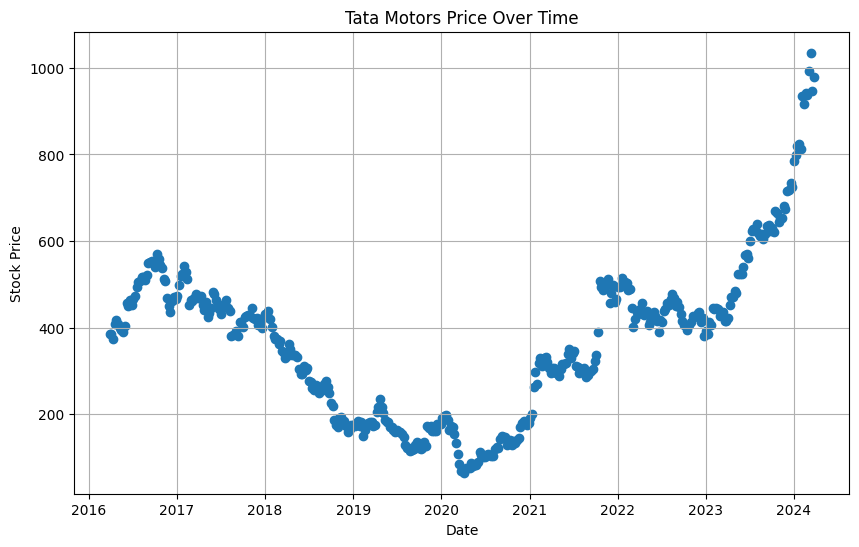

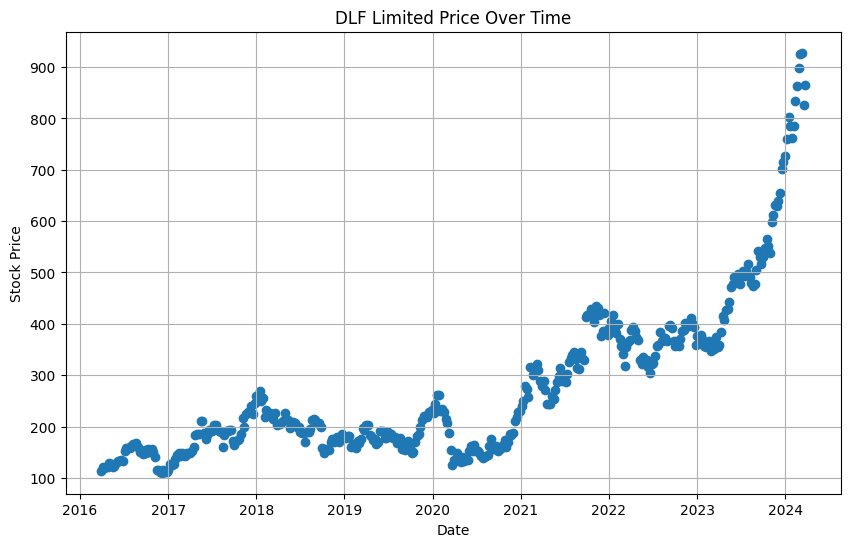

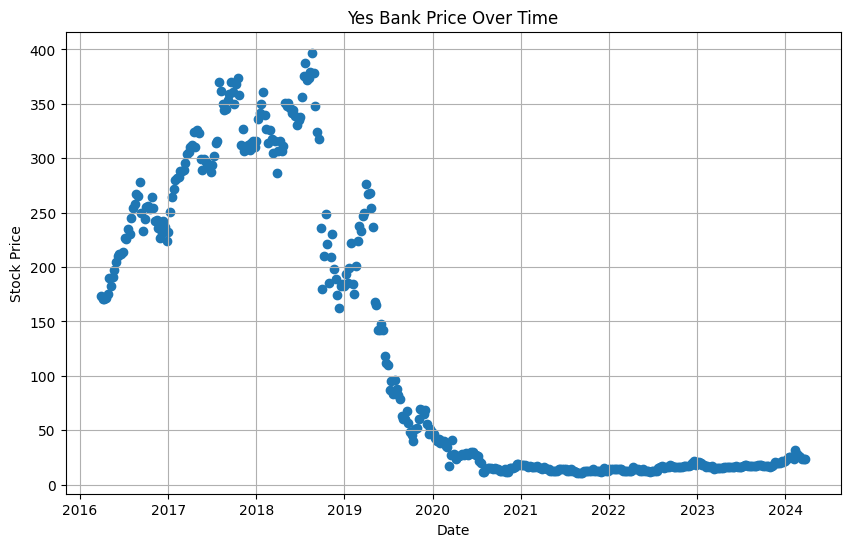

In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns

# Plotting scatter plot for all the columns against Date
for i, stock in enumerate(numeric_columns):
    plt.figure(figsize=(10, 6))
    plt.scatter(df['Date'], df[stock])
    plt.title(f'{stock} Price Over Time')
    plt.xlabel('Date')
    plt.ylabel('Stock Price')
    plt.grid(True)
    plt.show()


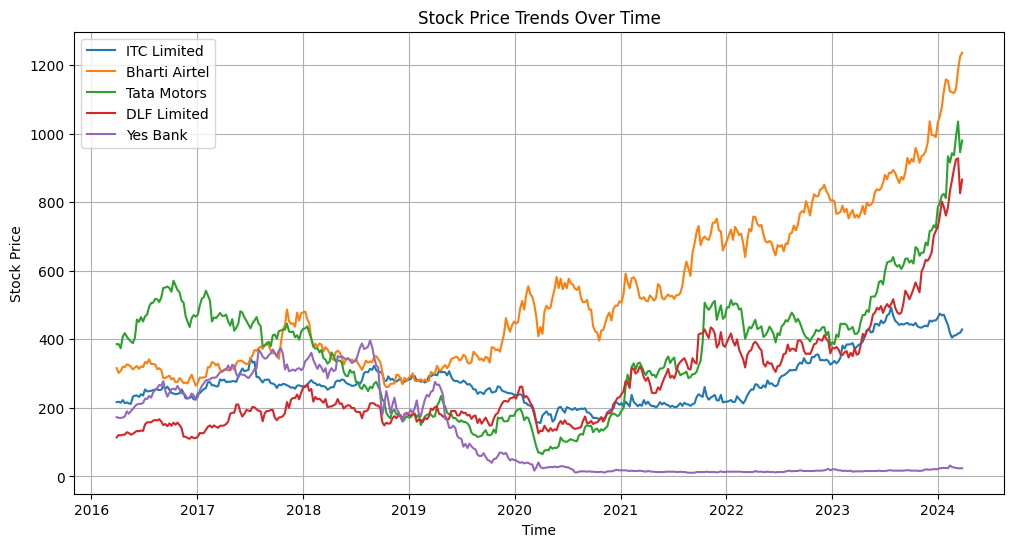

In [ ]:
# Set the date column as the index
df.set_index('Date', inplace=True)

# Plot stock prices over time
plt.figure(figsize=(12, 6))
for column in df.columns:
    plt.plot(df.index, df[column], label=column)

plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("Stock Price Trends Over Time")
plt.legend()
plt.grid()
plt.show()


**Inference**
-

The stock price graph reveals key trends over the 8-year period:

* Volatility Differences: Some stocks, such as Tata Motors and Yes Bank, show significant fluctuations, indicating high volatility.
* Diverging Performance: ITC Limited and Bharti Airtel appear relatively stable compared to others.
* Possible Market Events: Sharp drops or spikes in certain stocks suggest major market events impacting specific companies or sectors.

# Returns and Volatility Analysis


## Return Calculation

In [ ]:
# Return_of_Stocks =  np.log(df.drop(['Date'],axis=1)).diff(axis = 0)

# Set the display options to show all rows and columns
# pd.set_option('display.max_rows', None)  # Set to None to display all rows

# Return_of_Stocks

In [ ]:
Return_of_Stocks =  np.log(df).diff(axis = 0)

# Set the display options to show all rows and columns
pd.set_option('display.max_rows', None)  # Set to None to display all rows

Return_of_Stocks

,ITC Limited,Bharti Airtel,Tata Motors,DLF Limited,Yes Bank
Date,,,,,
2016-03-28,NaN,NaN,NaN,NaN,NaN
2016-04-04,0.004598,-0.045315,0.000000,0.059592,-0.011628
2016-04-11,-0.013857,0.019673,-0.031582,-0.008299,0.000000
2016-04-18,0.036534,0.038221,0.087011,0.016529,0.005831
2016-04-25,-0.041196,-0.003130,0.024214,0.000000,0.017291
2016-05-02,0.009302,0.024769,-0.024214,0.055791,0.082238
2016-05-09,-0.013986,-0.006135,-0.019803,-0.015625,-0.037538
2016-05-16,-0.004706,-0.015504,-0.015114,-0.040166,0.042787
2016-05-23,0.094452,-0.025318,-0.012772,0.016261,0.030930


## Average Returns

In [ ]:
# Mean for the returns for all stocks

StockMeans = Return_of_Stocks.mean()  ## Complete the code to get the mean for the returns for all stocks
StockMeans.sort_values()


,0
Yes Bank,-0.004737
ITC Limited,0.001634
Tata Motors,0.002234
Bharti Airtel,0.003271
DLF Limited,0.004863


## Volatility

In [ ]:
# Std. deviation for the returns for all stocks

StockStdDev = Return_of_Stocks.std()
StockStdDev.sort_values()


,0
ITC Limited,0.035904
Bharti Airtel,0.038728
DLF Limited,0.057785
Tata Motors,0.060484
Yes Bank,0.093879


## Visualizing Returns and Volatility

In [ ]:
data = pd.DataFrame({'Mean': StockMeans, 'Std. Dev': StockStdDev}) # dataframe for mean  and std. deviation for the returns of all stocks
data

,Mean,Std. Dev
ITC Limited,0.001634,0.035904
Bharti Airtel,0.003271,0.038728
Tata Motors,0.002234,0.060484
DLF Limited,0.004863,0.057785
Yes Bank,-0.004737,0.093879


Mean Returns Analysis:

* DLF Limited (0.004863) and Bharti Airtel (0.003271) have the highest average weekly returns, indicating strong growth potential.
* Yes Bank (-0.004737) has a negative mean return, signaling poor performance and declining investor confidence.

Risk (Standard Deviation) Assessment:

* Yes Bank (0.093879) exhibits the highest volatility, making it the riskiest stock in the portfolio.
* Tata Motors (0.060484) and DLF Limited (0.057785) also show considerable fluctuations, indicating higher risk but potential higher returns.
* ITC Limited (0.035904) and Bharti Airtel (0.038728) have lower standard deviations, making them more stable investment options.

Risk vs. Return Tradeoff:

* ITC Limited & Bharti Airtel: Lower risk, moderate returns → Suitable for risk-averse investors.
* Tata Motors & DLF Limited: Higher risk, higher return potential → Suitable for growth-oriented investors.
* Yes Bank: High risk with negative returns → Not suitable for conservative investors, high-risk speculative play.

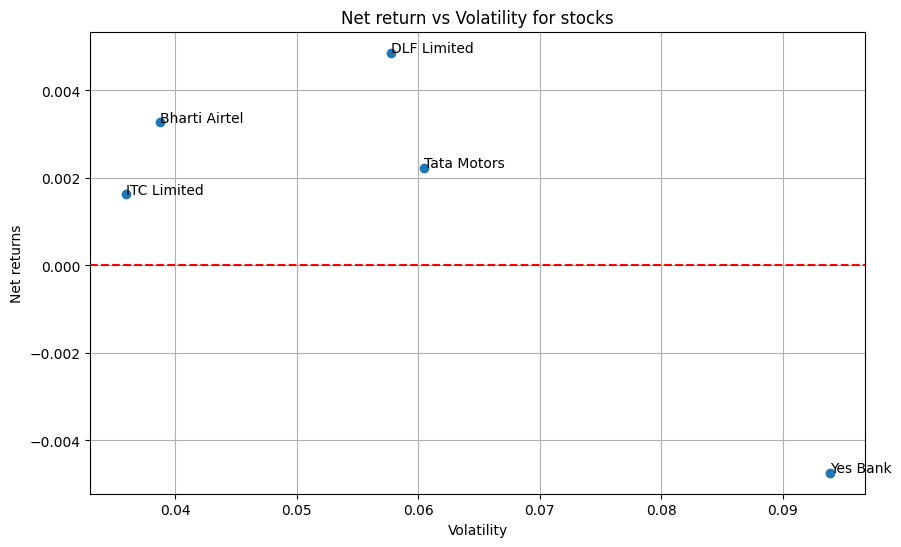

In [ ]:
import seaborn as sns

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111)
plt.scatter(data['Std. Dev'], data['Mean'])  ## Complete the code to get the plot of returns vs volatility for the returns for all stocks
plt.axhline(y=0,linestyle='--', color = "red")

# The 'data' DataFrame has columns 'Mean' and 'Std. Dev', not 'Volatility'
# Replace 'row['Volatility']' with 'row['Std. Dev']'
for index, row in data.iterrows():
    ax.text(row['Std. Dev'], row['Mean'], index)
plt.xlabel('Volatility')
plt.ylabel('Net returns')
plt.title('Net return vs Volatility for stocks')
plt.grid()
plt.show()

In [ ]:
# Calculate weekly returns for each stock
returns_df = df.pct_change().dropna()
returns_df

,ITC Limited,Bharti Airtel,Tata Motors,DLF Limited,Yes Bank
Date,,,,,
2016-04-04,0.004608,-0.044304,0.000000,0.061404,-0.011561
2016-04-11,-0.013761,0.019868,-0.031088,-0.008264,0.000000
2016-04-18,0.037209,0.038961,0.090909,0.016667,0.005848
2016-04-25,-0.040359,-0.003125,0.024510,0.000000,0.017442
2016-05-02,0.009346,0.025078,-0.023923,0.057377,0.085714
2016-05-09,-0.013889,-0.006116,-0.019608,-0.015504,-0.036842
2016-05-16,-0.004695,-0.015385,-0.015000,-0.039370,0.043716
2016-05-23,0.099057,-0.025000,-0.012690,0.016393,0.031414
2016-05-30,0.012876,0.019231,0.041131,0.040323,0.040609


In [ ]:
# Compute mean and standard deviation of returns
mean_returns = returns_df.mean()
std_dev_returns = returns_df.std()

# Display mean and standard deviation values
mean_returns, std_dev_returns

(ITC Limited      0.002281
 Bharti Airtel    0.004029
 Tata Motors      0.004088
 DLF Limited      0.006540
 Yes Bank        -0.000475
 dtype: float64,
 ITC Limited      0.036127
 Bharti Airtel    0.039073
 Tata Motors      0.061976
 DLF Limited      0.057796
 Yes Bank         0.091095
 dtype: float64)

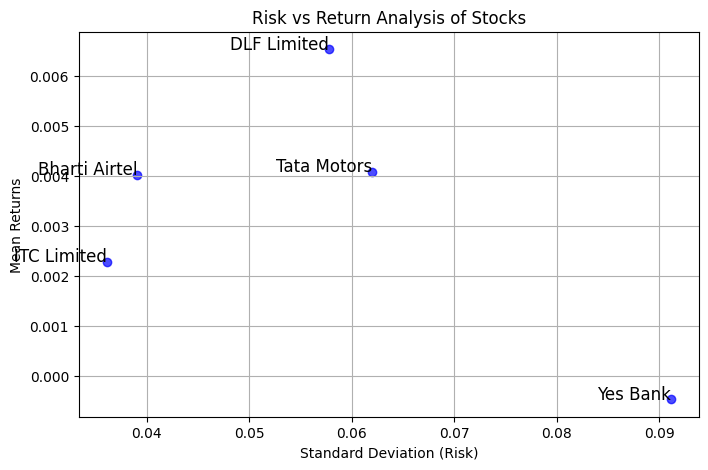

In [ ]:
# Plot Mean vs Standard Deviation of Returns
plt.figure(figsize=(8, 5))
plt.scatter(std_dev_returns, mean_returns, color='blue', alpha=0.7)
for stock in returns_df.columns:
    plt.text(std_dev_returns[stock], mean_returns[stock], stock, fontsize=12, ha='right')

plt.xlabel("Standard Deviation (Risk)")
plt.ylabel("Mean Returns")
plt.title("Risk vs Return Analysis of Stocks")
plt.grid()
plt.show()

**Inference**
-

Risk and Return Relationship:

* DLF Limited and Tata Motors exhibit higher mean returns but also higher risk (standard deviation).
* ITC Limited and Bharti Airtel have moderate risk levels with relatively stable returns.
* Yes Bank has the highest risk but a negative mean return, indicating poor performance.

Defensive vs. Aggressive Stocks:

* Defensive Stocks (Lower risk, stable returns): ITC Limited, Bharti Airtel.
* Aggressive Stocks (Higher risk, potential for higher returns): DLF Limited, Tata Motors.
* Underperforming Stock: Yes Bank shows negative mean returns with high volatility, making it highly risky.

# Conclusions and Recommendations

Portfolio Diversification

* Investors seeking stability should focus on ITC Limited and Bharti Airtel, as they have lower volatility and consistent returns.
* For higher returns with higher risk, Tata Motors and DLF Limited could be included in a well-balanced portfolio.
* Yes Bank should be approached cautiously due to its negative returns and high risk.

Risk Management

* Risk-averse investors should allocate more funds to ITC Limited and Bharti Airtel.
* Investors with a higher risk appetite can include DLF Limited and Tata Motors but should monitor their positions closely.
* Implement stop-loss strategies for highly volatile stocks to minimize downside risk.

Periodic Monitoring & Adjustments

* Regularly reassess portfolio allocations based on changing market conditions.
Rebalance the portfolio to maintain an optimal risk-return ratio.
* Track macroeconomic and sector-specific factors that could impact stock volatility.

___